# 05 — Presentation figures  ·  DS01

Deck-ready versions of the DS01 figures. Two things differ from `03A`/`03B`:

* **The matplotlib is in the cells, not in `src/`.** Nothing here calls `analysis.plot_*` or
  `spectra.plot_*`, so the typography, colours and layout of any figure can be edited where it is
  drawn. The *numerics* are still the library's — `spectra.psd_spectrum`, `band_amplitude` and
  `spectral_peaks` — so the numbers stay identical to the ones `03B` reports.
* **The data comes from `metrics.csv`.** None of these figures need the image cubes, so the
  notebook reads the ~1 MB of time series that `03B` already wrote instead of ~1.2 GB of FITS.
  It re-runs in about a second, which is what makes restyling bearable.

**Everything about the look lives in the next cell.** Edit it, re-run from there, and every
figure below follows.

## Style

One amber ramp, re-stepped so the four series separate. The colours as first drafted
(`#9A3412` / `#D97706` / `#F59E0B` / `#FBBF24`) were four steps of a *sequential* ramp used
categorically: `#D97706`~`#F59E0B` differed by only ΔE 10.8 and `#F59E0B`~`#FBBF24` by 8.0
(the normal-vision floor is 15), and the two lightest sat at 2.0:1 and 1.6:1 contrast against
the background — thin lines in those colours disappear on a projector.

The steps below are spread across the same amber family instead. Worst adjacent pair is now
ΔE 14.6 simulated for colour-vision deficiency, 15.2 for normal vision. Darkest is the umbra —
the subject — and lightest is the quiet Sun, the baseline, so visual weight follows meaning.

In [ ]:
"""Presentation style. This is the cell to edit; everything below follows from it."""

import pathlib

import matplotlib.pyplot as plt
from cycler import cycler
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.font_manager import FontProperties, findfont

# ── colour ────────────────────────────────────────────────────────────────────
C_SERIES_3 = '#7C2D12'   # Umbra     — darkest, the subject
C_SERIES_4 = '#B45309'   # Penumbra
C_SERIES_1 = '#E8890C'   # Both
C_SERIES_2 = '#FCD34D'   # Quiet Sun — lightest, the baseline
C_ACCENT   = '#D97706'   # single-series highlight
C_INK      = '#241A12'   # text and axes
C_GRID     = '#E7DCCC'   # grid
C_FIG_BG   = '#FDF8F1'   # figure background

PALETTE = [C_SERIES_1, C_SERIES_2, C_SERIES_3, C_SERIES_4]

# Region → colour, so "the umbra is always the darkest" holds in every figure.
REGION_COLOR = {
    'Umbra':     C_SERIES_1,
    'Penumbra':  C_SERIES_2,
    'Both':      C_SERIES_3,
    'Quiet Sun': C_SERIES_4,
}

# (label, metrics-key suffix), in drawing order.
REGIONS = [('Umbra', 'umb'), ('Penumbra', 'pen'),  ('Quiet Sun', 'quiet')]

# The same ramp as a sequential colormap — for quantities that are a magnitude
# (latitude, depth, hours since the first coefficient window), not an identity.
CMAP_AMBER = LinearSegmentedColormap.from_list(
    'amber', ['#451A03', C_SERIES_1, C_SERIES_2, C_SERIES_3, C_SERIES_4])

# ── typography ────────────────────────────────────────────────────────────────
# Jost is not installed on this machine, so the list falls through to IBM Plex Sans
# and upgrades by itself the day Jost is installed. JetBrains Mono is present only as
# the Nerd Font build; its letterforms are the same. The cell prints what resolved.
FONT_SANS = ['Jost', 'IBM Plex Sans', 'DejaVu Sans']
FONT_MONO = ['JetBrains Mono', 'JetBrainsMono Nerd Font', 'DejaVu Sans Mono']

# ── sizes ─────────────────────────────────────────────────────────────────────
FS_TITLE  = 26
FS_LABEL  = 20
FS_TICK   = 17
FS_LEGEND = 18
FS_ANNOT  = 14

LW_SERIES = 2.4
LW_GRID   = 1.0
LW_SPINE  = 1.6

FIGSIZE_WIDE  = (16, 8)
FIGSIZE_STACK = (16, 10)
DPI_SHOW = 110
DPI_SAVE = 200

# ── output ────────────────────────────────────────────────────────────────────
SAVE = False
PLOTS_DIR = None          # the data cell points this at DS01/plots

plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.sans-serif':  FONT_SANS,
    'font.monospace':   FONT_MONO,
    'font.size':        FS_LABEL,

    'figure.figsize':     FIGSIZE_WIDE,
    'figure.dpi':         DPI_SHOW,
    'figure.facecolor':   C_FIG_BG,
    'figure.titlesize':   FS_TITLE,
    'figure.titleweight': 'semibold',

    'savefig.facecolor': C_FIG_BG,
    'savefig.dpi':       DPI_SAVE,
    'savefig.bbox':      'tight',

    'axes.facecolor':     C_FIG_BG,
    'axes.edgecolor':     C_INK,
    'axes.linewidth':     LW_SPINE,
    'axes.labelcolor':    C_INK,
    'axes.labelsize':     FS_LABEL,
    'axes.labelweight':   'medium',
    'axes.titlesize':     FS_TITLE,
    'axes.titleweight':   'semibold',
    'axes.titlecolor':    C_INK,
    'axes.titlepad':      14,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.prop_cycle':    cycler(color=PALETTE),
    'axes.grid':          True,
    'axes.axisbelow':     True,

    'grid.color':     C_GRID,
    'grid.linewidth': LW_GRID,
    'grid.alpha':     1.0,

    'lines.linewidth':       LW_SERIES,
    'lines.solid_capstyle':  'round',

    'text.color':        C_INK,
    'xtick.color':       C_INK,
    'ytick.color':       C_INK,
    'xtick.labelsize':   FS_TICK,
    'ytick.labelsize':   FS_TICK,
    'xtick.major.width': LW_SPINE,
    'ytick.major.width': LW_SPINE,
    'xtick.major.size':  6,
    'ytick.major.size':  6,

    'legend.fontsize':   FS_LEGEND,
    'legend.frameon':    True,
    'legend.facecolor':  C_FIG_BG,
    'legend.edgecolor':  C_GRID,
    'legend.framealpha': 1.0,
    'legend.borderpad':  0.6,
})


def mono_ticks(*axes):
    """Put the mono face on the tick labels — matplotlib has no rcParam for this."""
    for ax in axes:
        for label in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
            label.set_fontfamily('monospace')
            label.set_fontsize(FS_TICK)


def save_fig(fig, name):
    """Write `name`.png into PLOTS_DIR. No-op unless SAVE."""
    if not SAVE or PLOTS_DIR is None:
        return
    out_dir = pathlib.Path(PLOTS_DIR)
    out_dir.mkdir(parents=True, exist_ok=True)
    out = out_dir / f'{name}.png'
    fig.savefig(out, dpi=DPI_SAVE, bbox_inches='tight', facecolor=C_FIG_BG)
    print(f'saved → {out}')


# Which families actually resolved? A silent fallback should be visible here, not in the deck.
for role, stack in (('sans', FONT_SANS), ('mono', FONT_MONO)):
    resolved = pathlib.Path(findfont(FontProperties(family=stack))).name
    print(f'{role:5s} {stack[0]:20s} → {resolved}')

sans  Jost                 → IBMPlexSans-Regular.ttf
mono  JetBrains Mono       → JetBrainsMonoNerdFont-Regular.ttf


## Data — DS01

`metrics.csv` is what `03B` wrote for `DS_INDEX = 1`: one row per frame, 1067 frames at a
720 s cadence, 213.2 h in all. `add_mag_residuals` reads nothing but `data['time_h']`, so a
two-key `data` dict is enough to get the parabola-subtracted magnetogram series that the
polynomial-removal and comparison figures need.

In [ ]:
import pathlib
import sys

project_root = pathlib.Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root.resolve()))

import numpy as np
import pandas as pd

from src import analysis, config, spectra

DATASET   = 'DS01'
OUT_DIR   = config.DS0N_PROCESSED_DIR / DATASET
CSV_PATH  = OUT_DIR / 'metrics.csv'
PLOTS_DIR = OUT_DIR / 'plots'          # save_fig() reads this global

df      = pd.read_csv(CSV_PATH)
time_h  = df['time_h'].to_numpy()
metrics = {c: df[c].to_numpy() for c in df.columns if c != 'time_h'}

# Only data['time_h'] is read, which is what makes the CSV path viable.
data      = {'time_h': time_h, 'cadence_s': 720.0}
metrics   = analysis.add_mag_residuals(data, metrics)      # adds mean_mag_<region>_residual
cadence_s = data['cadence_s']

print(f'{DATASET}: {len(time_h)} frames | {time_h[-1]:.1f} h | cadence {cadence_s:.0f} s')
print(f'series: {", ".join(sorted(metrics))}')

DS01: 1067 frames | 213.2 h | cadence 720 s
series: area_both, area_hotspot, area_pen, area_umb, mean_dop_both, mean_dop_pen, mean_dop_quiet, mean_dop_umb, mean_mag_both, mean_mag_both_residual, mean_mag_hotspot, mean_mag_hotspot_residual, mean_mag_pen, mean_mag_pen_residual, mean_mag_quiet, mean_mag_quiet_residual, mean_mag_umb, mean_mag_umb_residual


## Mean signal per region

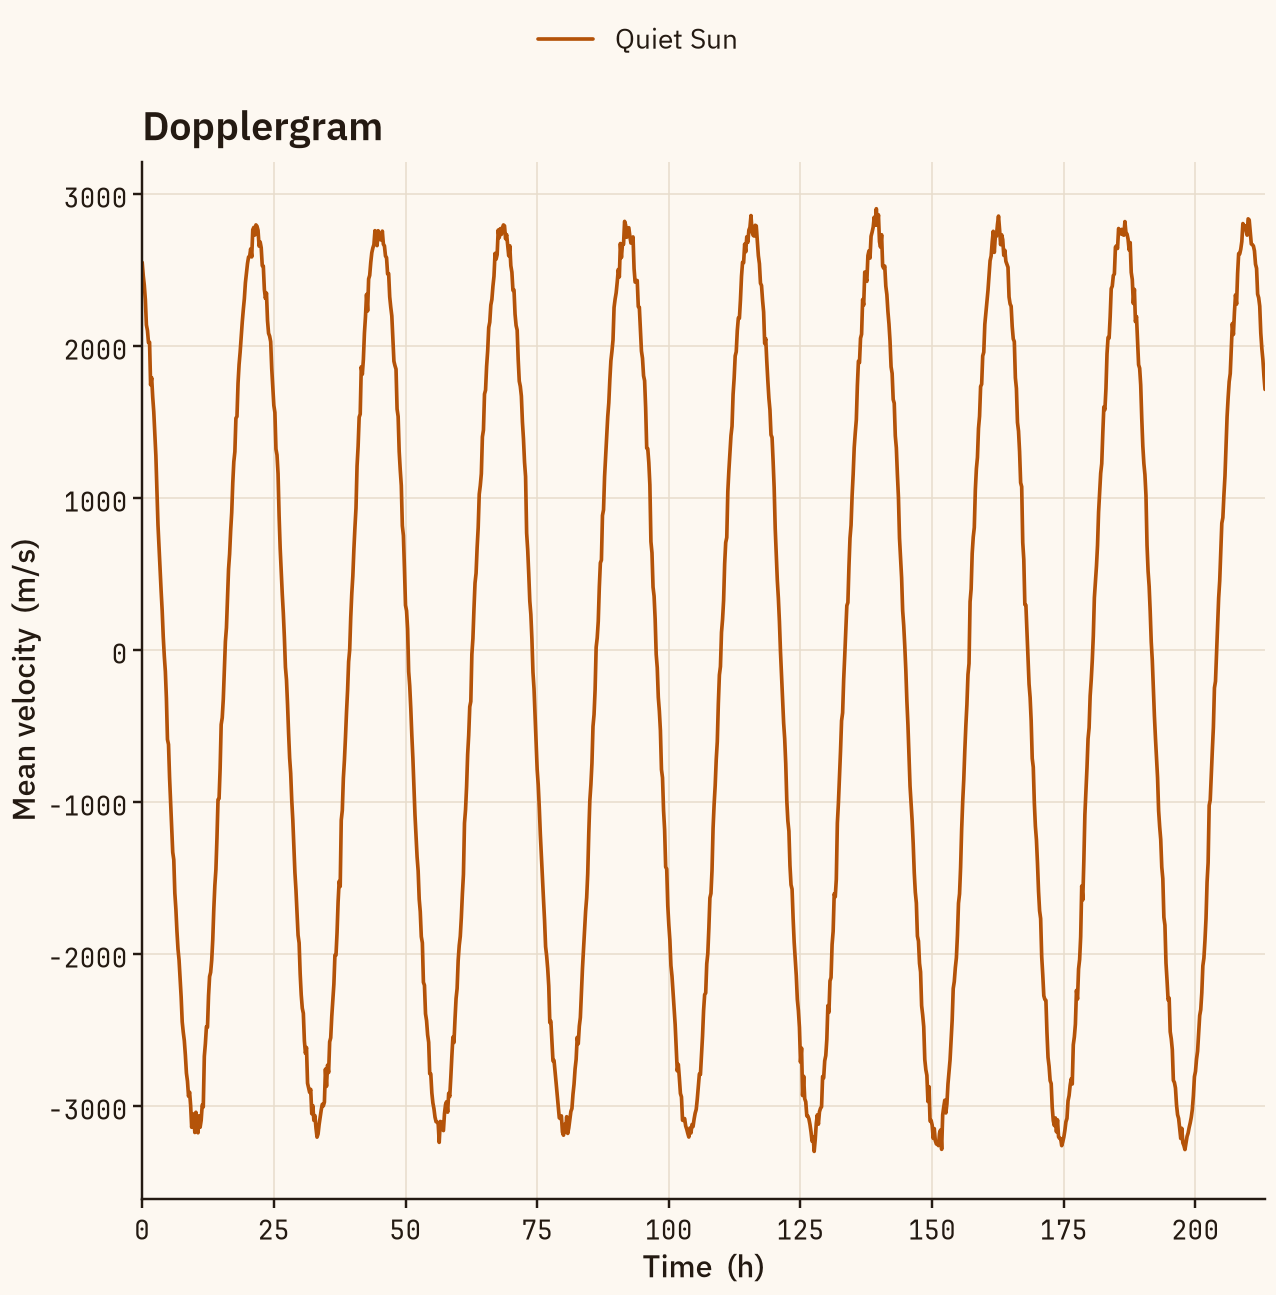

In [ ]:
# DS01 — mean field and mean velocity, four regions, raw
fig, (ax_dop) = plt.subplots(1, 1, figsize=(12,12), sharex=True)

for label, suffix in REGIONS[-1:]:
    colour = REGION_COLOR[label]
    ax_dop.plot(time_h, metrics[f'mean_dop_{suffix}'], color=colour, lw=LW_SERIES, label=label)


ax_dop.set_ylabel('Mean velocity  (m/s)')
ax_dop.set_xlabel('Time  (h)')
ax_dop.set_title('Dopplergram', loc='left')

for ax in [ax_dop]:
    ax.set_xlim(time_h[0], time_h[-1])

# One legend for both panels, on the title line and outside the data area.
mono_ticks( ax_dop)
fig.tight_layout(rect=(0, 0, 1, 0.94))

# One legend for both panels, in its own band above the titles.
fig.legend(*ax_dop.get_legend_handles_labels(), ncol=4,
           loc='upper center', bbox_to_anchor=(0.5, 1.0), frameon=False)
save_fig(fig, 'ds01_time_series')
plt.show()

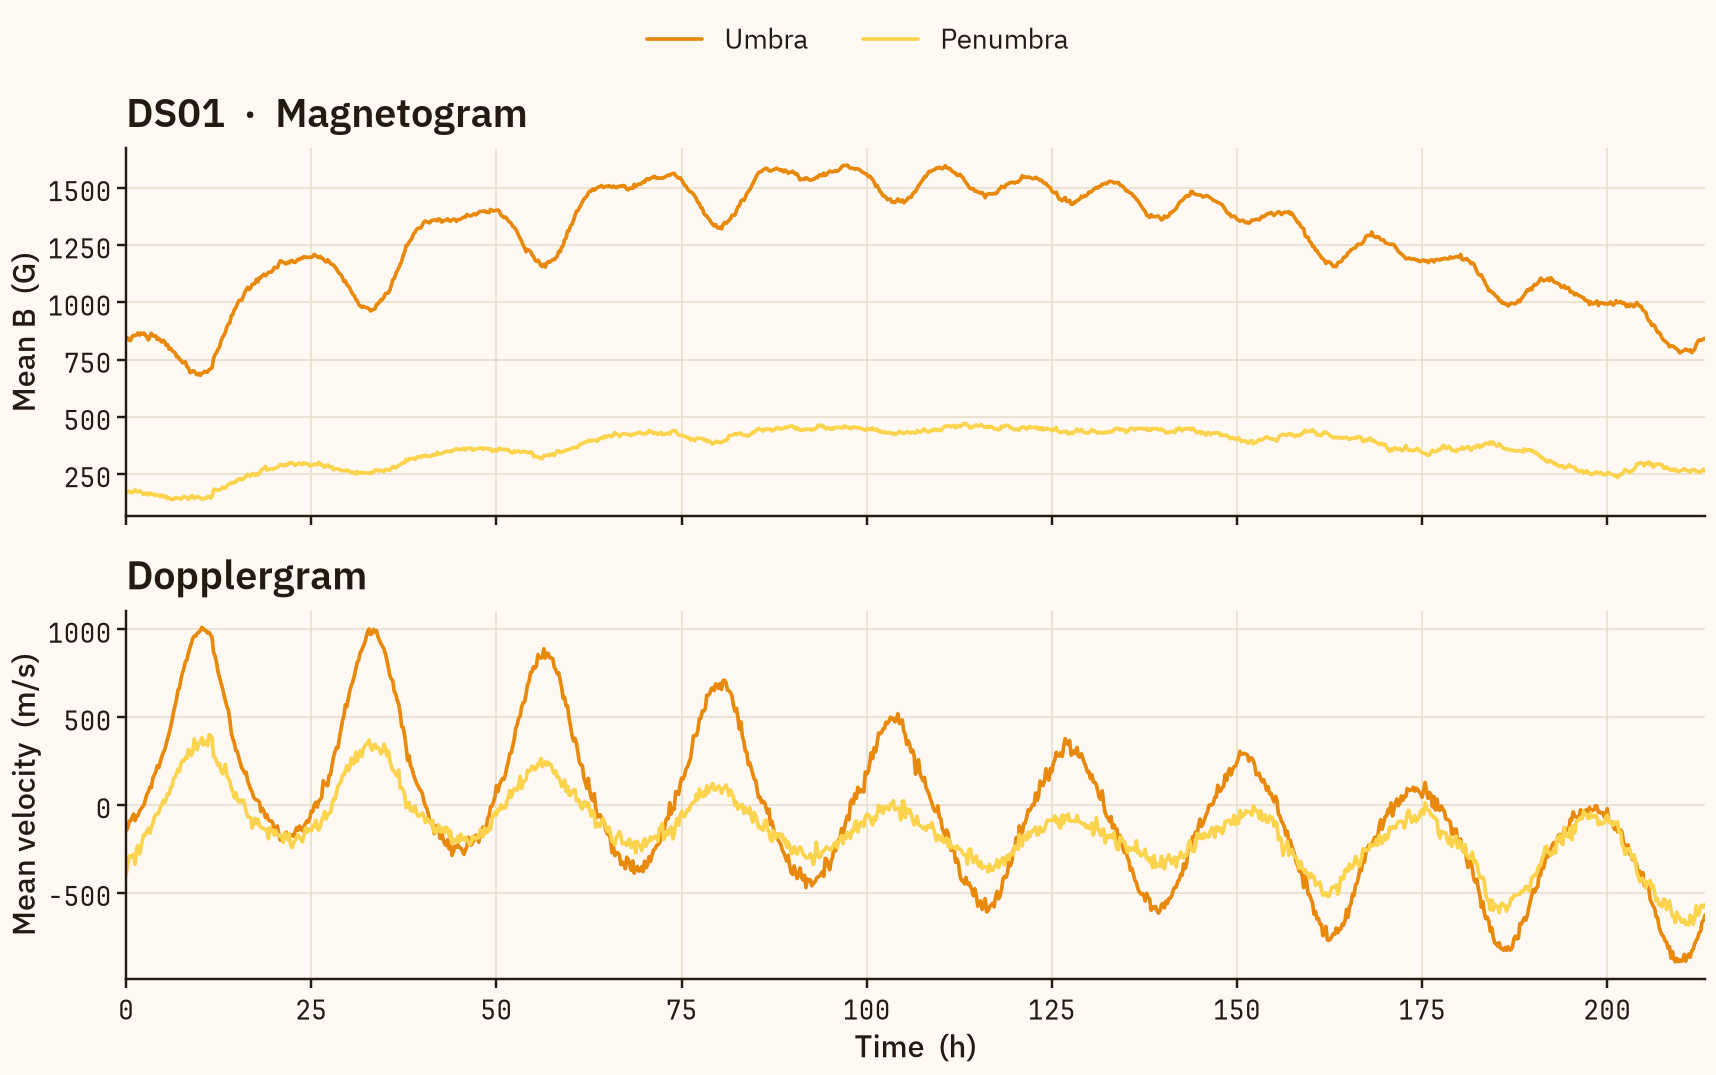

In [ ]:
# DS01 — mean field and mean velocity, four regions, raw
fig, (ax_mag, ax_dop) = plt.subplots(2, 1, figsize=FIGSIZE_STACK, sharex=True)

for label, suffix in REGIONS[:-1]:
    colour = REGION_COLOR[label]
    ax_mag.plot(time_h, metrics[f'mean_mag_{suffix}'], color=colour, lw=LW_SERIES, label=label)
    ax_dop.plot(time_h, metrics[f'mean_dop_{suffix}'], color=colour, lw=LW_SERIES, label=label)

ax_mag.set_ylabel('Mean B  (G)')
ax_mag.set_title(f'{DATASET}  ·  Magnetogram', loc='left')

ax_dop.set_ylabel('Mean velocity  (m/s)')
ax_dop.set_xlabel('Time  (h)')
ax_dop.set_title('Dopplergram', loc='left')

for ax in (ax_mag, ax_dop):
    ax.set_xlim(time_h[0], time_h[-1])

# One legend for both panels, on the title line and outside the data area.
mono_ticks(ax_mag, ax_dop)
fig.tight_layout(rect=(0, 0, 1, 0.94))

# One legend for both panels, in its own band above the titles.
fig.legend(*ax_mag.get_legend_handles_labels(), ncol=4,
           loc='upper center', bbox_to_anchor=(0.5, 1.0), frameon=False)
save_fig(fig, 'ds01_time_series')
plt.show()

### Is the slow magnetogram trend just the viewing geometry?

The mean field over the spot drifts across the window in something close to a parabola, and the
figure above removes it by *fitting* a degree-2 polynomial. But μ = cos(heliocentric angle) draws
a parabola too, because the spot rotates from one side of the disk toward the other — over DS01's
213 h μ runs **0.50 → 0.97 → 0.46**, so the spot crosses disk centre near the middle of the window
and is foreshortened by a factor of two at both ends.

If the line-of-sight field is `B_los = B · μ`, then dividing by μ is the *physical* correction
where subtracting a parabola is only a curve fit. What survives the division is the real
variation.

The cell below builds the region masks from the continuum cube and streams `cube_mu.fits` frame
by frame, computing `mean(B/μ)` over each mask — the per-pixel de-projection, not
`mean(B)/mean(μ)`. It caches the result to `mu_means.csv`, so the cost is paid once.

The quiet Sun gets no μ series: it is measured on its own separate 60×60 cube and has no mask in
the region data, so there is nothing to average μ over.

In [ ]:
"""Masks + μ → mean(B/μ) per region, cached. Heavy the first time, instant afterwards."""

import gc
import warnings

RECOMPUTE_MU = False                      # True forces a rebuild even if the cache exists
RAW_DIR  = config.DS0N_RAW_DIR / DATASET
MU_CSV   = OUT_DIR / 'mu_means.csv'
MU_FLOOR = 0.05                           # guard; DS01's μ never drops below ~0.39
SUFFIXES = ['umb', 'pen', 'both']         # no 'quiet' — it has no mask in the region data

if RECOMPUTE_MU or not MU_CSV.exists():
    from astropy.io import fits

    from src.config import loader_kwargs, params_for
    from src.loaders import _load_cube            # same helper load_ds0n_region uses,
    from src.segmentation import masks_from_cubes # so the masks match metrics.csv exactly

    params    = params_for(RAW_DIR, line='B')
    cube_cont = _load_cube(RAW_DIR / 'cube_continuum.fits', 1e6)
    cube_mag  = _load_cube(RAW_DIR / 'cube_magnetogram.fits', 1e6)

    # umbra/penumbra/both come from the continuum alone; the dopplergram and quiet-Sun
    # cubes are only stored by masks_from_cubes, never read — so None is safe and saves
    # three 233 MB reads.
    region = masks_from_cubes(cube_cont, cube_mag, None, None, None,
                              **loader_kwargs(params))
    del cube_cont
    gc.collect()

    n_t   = region['n_t']
    masks = {'umb': region['umbra'], 'pen': region['penumbra'], 'both': region['both']}

    cols = {f'mu_{s}': np.full(n_t, np.nan) for s in SUFFIXES}
    cols.update({f'mean_magmu_{s}': np.full(n_t, np.nan) for s in SUFFIXES})
    check_mag = np.full(n_t, np.nan)       # recomputed mean_mag_umb, to prove the masks match

    # Streamed frame by frame. The whole μ cube as float64 would be ~490 MB and the
    # per-pixel B/μ cube another ~490 MB, for a result that is only 3 × n_t numbers.
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)     # all-NaN masks are expected
        with fits.open(RAW_DIR / 'cube_mu.fits', memmap=True) as hdul:
            mu_data = hdul[0].data
            for t in range(n_t):
                mu = np.asarray(mu_data[t], dtype=np.float64)
                mu[(np.abs(mu) > 1e6) | (mu <= MU_FLOOR)] = np.nan   # IDL fill + guard
                b_over_mu = cube_mag[t] / mu

                for s in SUFFIXES:
                    m = masks[s][t]
                    if not m.any():
                        continue
                    cols[f'mu_{s}'][t]         = np.nanmean(mu[m])
                    cols[f'mean_magmu_{s}'][t] = np.nanmean(b_over_mu[m])

                m = masks['umb'][t]
                if m.any():
                    check_mag[t] = np.nanmean(cube_mag[t][m])

    pd.DataFrame({'time_h': region['time_h'], **cols}).to_csv(
        MU_CSV, index=False, float_format='%.4f')
    print(f'μ means written → {MU_CSV}  ({n_t} rows)')

    # Do the masks really match the ones behind metrics.csv? If not, the μ means are
    # averaged over different pixels and the figure below is wrong.
    deviation = np.nanmax(np.abs(check_mag - df['mean_mag_umb'].to_numpy()))
    print(f'mask check: max |recomputed − metrics.csv| mean_mag_umb = {deviation:.4f} G '
          f'({"match" if deviation < 1e-3 else "MISMATCH — do not trust the figure"})')

    del cube_mag, region, masks
    gc.collect()
else:
    print(f'using cached {MU_CSV.name} — set RECOMPUTE_MU = True to rebuild')

mu_df = pd.read_csv(MU_CSV)
metrics.update({c: mu_df[c].to_numpy() for c in mu_df.columns if c != 'time_h'})

mid = len(time_h) // 2
print(f'mean μ (umbra):  t=0 {metrics["mu_umb"][0]:.3f}  |  '
      f't={time_h[mid]:.0f} h {metrics["mu_umb"][mid]:.3f}  |  '
      f't={time_h[-1]:.0f} h {metrics["mu_umb"][-1]:.3f}')

using cached mu_means.csv — set RECOMPUTE_MU = True to rebuild
mean μ (umbra):  t=0 0.497  |  t=107 h 0.975  |  t=213 h 0.465


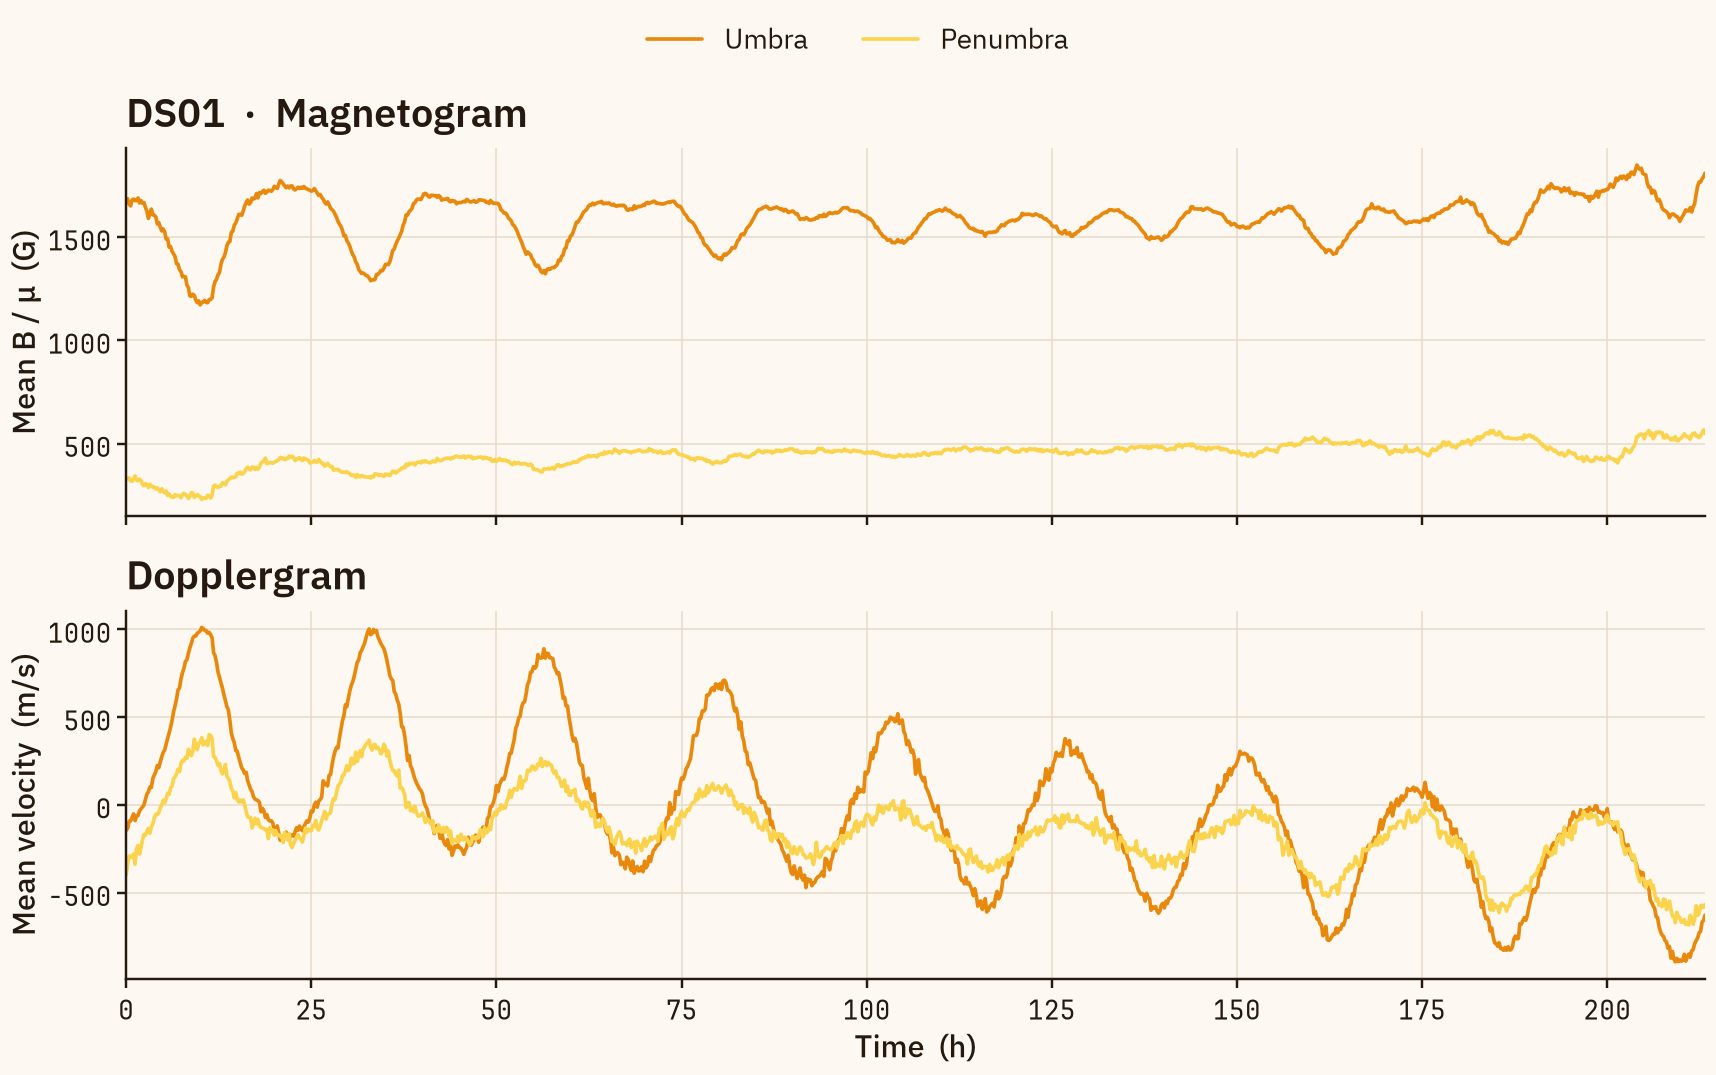

region            raw B  a·t²        B/μ  a·t²  |reduction|
────────────────────────────────────────────────────────────
Umbra              -0.0665           0.0043       15.34×
Penumbra           -0.0230          -0.0057        4.01×


In [ ]:
# DS01 — μ-corrected field above, velocity below
fig, (ax_mag, ax_dop) = plt.subplots(2, 1, figsize=FIGSIZE_STACK, sharex=True)

# Top: B/μ, umbra / penumbra / both. The quiet Sun has no μ series (no mask of its own).
for label, suffix in REGIONS:
    if suffix == 'quiet':
        continue
    ax_mag.plot(time_h, metrics[f'mean_magmu_{suffix}'],
                color=REGION_COLOR[label], lw=LW_SERIES, label=label)

# Bottom: velocity, all four regions.
for label, suffix in REGIONS[:-1]:
    ax_dop.plot(time_h, metrics[f'mean_dop_{suffix}'],
                color=REGION_COLOR[label], lw=LW_SERIES, label=label)

ax_mag.set_ylabel('Mean B / μ  (G)')
ax_mag.set_title(f' Magnetogram', loc='left')

ax_dop.set_ylabel('Mean velocity  (m/s)')
ax_dop.set_xlabel('Time  (h)')
ax_dop.set_title('Dopplergram', loc='left')

for ax in (ax_mag, ax_dop):
    ax.set_xlim(time_h[0], time_h[-1])

mono_ticks(ax_mag, ax_dop)
fig.tight_layout(rect=(0, 0, 1, 0.94))

# The bottom panel's four series are the superset, so one legend covers both panels.
fig.legend(*ax_dop.get_legend_handles_labels(), ncol=4,
           loc='upper center', bbox_to_anchor=(0.5, 1.0), frameon=False)

save_fig(fig, 'ds01_mag_over_mu')
plt.show()

# Did dividing by μ actually flatten the parabola, or does it survive?
print(f'{"region":<12} {"raw B  a·t²":>16} {"B/μ  a·t²":>16} {"|reduction|":>12}')
print('─' * 60)
for label, suffix in REGIONS:
    if suffix == 'quiet':
        continue
    raw, corrected = metrics[f'mean_mag_{suffix}'], metrics[f'mean_magmu_{suffix}']
    good = np.isfinite(raw) & np.isfinite(corrected)
    a_raw = np.polyfit(time_h[good], raw[good], 2)[0]
    a_cor = np.polyfit(time_h[good], corrected[good], 2)[0]
    print(f'{label:<12} {a_raw:>13.4f} {a_cor:>16.4f} {abs(a_raw) / abs(a_cor):>11.2f}×')

### Removing HMI's calibration polynomial

`REMOVE_POLINOMIAL`, as `03A` and `04` use it, means something different from the parabola fit:
it undoes **HMI's cubic Doppler calibration** by inverting it per pixel, before any averaging.
DS01 already has the inverted cubes on disk — `cube_dopplergram_reconstructed.fits` and
`cube_magnetogram_reconstructed.fits`, written by `01T` — so the cells below read those rather
than re-running `reconstruct_cubes` (which needs `timestamps`, a key the DS0N loader never
provides).

> **These are experimental values, not data.** `src/post_processing.py` says so in its own module
> docstring: reconstructing DS01's dopplergram this way *does not* reproduce the shipped
> `cube_dopplergram_corrected.fits`, and the correlation between the two is about zero.
> Measured here on DS01's umbra mask: the reconstructed velocity spans **−18541 to +13747 m/s**
> against the corrected cube's −894 to +1012, and the reconstructed field is negative everywhere
> with **67 % of its jump offsets alternating in sign**.
>
> That alternation is the point. `invert_cubic` chooses, among three real roots, whichever is
> nearest the measured value — a per-frame choice with no temporal continuity, so the series flips
> between branches rather than settling. `remove_jumps` is applied below exactly as `04` applies
> it, but its own docstring is explicit that de-stepping a sign-alternating series is *conditioning,
> not repair*: each segment keeps whatever branch it was reconstructed on, so only relative levels
> survive. Read the `alternating` column before believing any of these curves.

In [ ]:
"""Reconstructed cubes → per-region means, cached to DS01_RemPol. Heavy once, instant after."""

RECOMPUTE_REMPOL = False               # True forces a rebuild even if the cache exists
REMPOL_DIR = config.DS0N_PROCESSED_DIR / f'{DATASET}_RemPol'
REMPOL_CSV = REMPOL_DIR / 'metrics.csv'
# RAW_DIR, MU_FLOOR and SUFFIXES come from the μ cell above.

if RECOMPUTE_REMPOL or not REMPOL_CSV.exists():
    import gc
    import warnings

    from astropy.io import fits

    from src.config import loader_kwargs, params_for
    from src.loaders import _load_cube
    from src.segmentation import masks_from_cubes

    params    = params_for(RAW_DIR, line='B')
    cube_cont = _load_cube(RAW_DIR / 'cube_continuum.fits', 1e6)
    cube_mag0 = _load_cube(RAW_DIR / 'cube_magnetogram.fits', 1e6)   # original, for the mask check

    # The reconstruction never touched the continuum, so these are the same masks as
    # DS01/metrics.csv — which is what makes the two files comparable row for row.
    region = masks_from_cubes(cube_cont, cube_mag0, None, None, None, **loader_kwargs(params))
    del cube_cont
    gc.collect()

    n_t      = region['n_t']
    masks    = {'umb': region['umbra'], 'pen': region['penumbra'], 'both': region['both']}
    hot_spot = region['hot_spot']

    cols = {k: np.full(n_t, np.nan) for k in
            [f'mean_dop_{s}'   for s in SUFFIXES] +
            [f'mean_mag_{s}'   for s in SUFFIXES] +
            [f'mean_magmu_{s}' for s in SUFFIXES] + ['mean_mag_hotspot']}
    check_mag = np.full(n_t, np.nan)

    # All three cubes are memmapped and read one frame at a time, so three open cubes cost
    # no more than one. mean(B/μ) has to happen in here — it is a per-pixel divide and
    # cannot be recovered afterwards from a mean μ.
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        with fits.open(RAW_DIR / 'cube_dopplergram_reconstructed.fits', memmap=True) as h_dop, \
             fits.open(RAW_DIR / 'cube_magnetogram_reconstructed.fits', memmap=True) as h_mag, \
             fits.open(RAW_DIR / 'cube_mu.fits', memmap=True) as h_mu:
            dop_data, mag_data, mu_data = h_dop[0].data, h_mag[0].data, h_mu[0].data

            for t in range(n_t):
                dop = np.asarray(dop_data[t], dtype=np.float64)
                mag = np.asarray(mag_data[t], dtype=np.float64)
                mu  = np.asarray(mu_data[t],  dtype=np.float64)
                dop[np.abs(dop) > 1e6] = np.nan
                mag[np.abs(mag) > 1e6] = np.nan
                mu[(np.abs(mu) > 1e6) | (mu <= MU_FLOOR)] = np.nan
                mag_over_mu = mag / mu

                for s in SUFFIXES:
                    m = masks[s][t]
                    if not m.any():
                        continue
                    cols[f'mean_dop_{s}'][t]   = np.nanmean(dop[m])
                    cols[f'mean_mag_{s}'][t]   = np.nanmean(mag[m])
                    cols[f'mean_magmu_{s}'][t] = np.nanmean(mag_over_mu[m])

                if hot_spot is not None and hot_spot[t].any():
                    cols['mean_mag_hotspot'][t] = np.nanmean(mag[hot_spot[t]])

                m = masks['umb'][t]
                if m.any():
                    check_mag[t] = np.nanmean(cube_mag0[t][m])

    # The quiet Sun ships no reconstructed cube, so run the inversion on it here. Cheap —
    # the qsun cubes are 60x60, ~16x fewer pixels per frame than the spot box — but it
    # needs a JSOC query for the coefficient rows, so this is the one part of the cell
    # that wants a network connection. If that query fails, let it raise: falling back to
    # the untouched cubes would file un-reconstructed data under a reconstructed name.
    import datetime as _dt

    from astropy.time import Time
    from scipy.io import readsav

    from src.post_processing import reconstruct_cubes

    dop_qsun = _load_cube(RAW_DIR / 'cube_dopplergram_qsun.fits', 1e6)
    mag_qsun = _load_cube(RAW_DIR / 'cube_magnetogram_qsun.fits', 1e6)
    assert len(dop_qsun) == n_t, f'qsun cube has {len(dop_qsun)} frames, region has {n_t}'

    # The dopplergram's own per-frame timestamps, not the continuum's — the inversion acts
    # on dopplergram/magnetogram-derived velocities specifically. Same source 01T used.
    _times = readsav(RAW_DIR / 'cube_dopplergram_coords2times.sav')['times'].flatten().astype(str)
    obs_times = Time([_dt.datetime.strptime(t, '%d-%b-%Y %H:%M:%S.%f') for t in _times],
                     scale='tai')
    dop_qsun_rec, mag_qsun_rec = reconstruct_cubes(dop_qsun, mag_qsun, obs_times)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        cols['mean_dop_quiet'] = np.array([np.nanmean(dop_qsun_rec[t]) for t in range(n_t)])
        cols['mean_mag_quiet'] = np.array([np.nanmean(mag_qsun_rec[t]) for t in range(n_t)])
        # Keep the untouched series alongside. Now that the quiet Sun is reconstructed too,
        # these are the only columns the inversion never rewrote, so their jump count is
        # what is left of 04's free check that the de-stepping filter invents nothing.
        cols['mean_dop_quiet_orig'] = np.array([np.nanmean(dop_qsun[t]) for t in range(n_t)])
        cols['mean_mag_quiet_orig'] = np.array([np.nanmean(mag_qsun[t]) for t in range(n_t)])

    # Areas come from the continuum masks and are unchanged, so the file is a drop-in twin
    # of DS01/metrics.csv.
    for s in SUFFIXES:
        cols[f'area_{s}'] = masks[s].sum(axis=(1, 2)).astype(float)
    if hot_spot is not None:
        cols['area_hotspot'] = hot_spot.sum(axis=(1, 2)).astype(float)

    REMPOL_DIR.mkdir(parents=True, exist_ok=True)
    pd.DataFrame({'time_h': region['time_h'], **cols}).to_csv(
        REMPOL_CSV, index=False, float_format='%.4f')
    print(f'reconstructed metrics written → {REMPOL_CSV}  ({n_t} rows)')

    deviation = np.nanmax(np.abs(check_mag - df['mean_mag_umb'].to_numpy()))
    print(f'mask check: max |recomputed − metrics.csv| mean_mag_umb = {deviation:.4f} G '
          f'({"match" if deviation < 1e-3 else "MISMATCH — do not trust the figures"})')

    del cube_mag0, region, masks, hot_spot, dop_qsun, mag_qsun, dop_qsun_rec, mag_qsun_rec
    gc.collect()
else:
    print(f'using cached {REMPOL_CSV.parent.name}/{REMPOL_CSV.name} — '
          f'set RECOMPUTE_REMPOL = True to rebuild')

# Kept in its own dict: mu_means.csv also has mean_magmu_* keys, meaning the ORIGINAL field
# divided by μ. Merging these into `metrics` would silently overwrite the μ figure's data.
rempol = {c: s.to_numpy() for c, s in pd.read_csv(REMPOL_CSV).items() if c != 'time_h'}

print(f'umbra, reconstructed:  velocity {np.nanmin(rempol["mean_dop_umb"]):9.1f} .. '
      f'{np.nanmax(rempol["mean_dop_umb"]):9.1f} m/s   |   '
      f'field {np.nanmin(rempol["mean_mag_umb"]):8.1f} .. '
      f'{np.nanmax(rempol["mean_mag_umb"]):8.1f} G')
print(f'umbra, corrected/original: velocity {np.nanmin(metrics["mean_dop_umb"]):9.1f} .. '
      f'{np.nanmax(metrics["mean_dop_umb"]):9.1f} m/s   |   '
      f'field {np.nanmin(metrics["mean_mag_umb"]):8.1f} .. '
      f'{np.nanmax(metrics["mean_mag_umb"]):8.1f} G')

using cached DS01_RemPol/metrics.csv — set RECOMPUTE_REMPOL = True to rebuild
umbra, reconstructed:  velocity  -18540.8 ..   13746.9 m/s   |   field  -7779.7 ..  -1055.8 G
umbra, corrected/original: velocity    -893.6 ..    1011.7 m/s   |   field    680.6 ..   1599.6 G


In [ ]:
# Condition the reconstructed series the way notebook 04 does, then plot.
REMOVE_JUMPS = True
JUMP_KEYS = ('mean_dop_umb', 'mean_dop_pen', 'mean_dop_both', 'mean_dop_quiet',
             'mean_mag_umb', 'mean_mag_pen', 'mean_mag_both', 'mean_mag_quiet',
             'mean_mag_hotspot',
             'mean_magmu_umb', 'mean_magmu_pen', 'mean_magmu_both',
             'mean_dop_quiet_orig', 'mean_mag_quiet_orig')   # the un-reconstructed control

rempol_raw = {k: v.copy() for k, v in rempol.items()}      # keep the pre-jump values
jump_rows = []
if REMOVE_JUMPS:
    for key in JUMP_KEYS:
        if key not in rempol:
            continue
        rempol[key], jumps = spectra.remove_jumps(time_h, rempol_raw[key])
        offsets = jumps['offset'].to_numpy() if not jumps.empty else np.array([])
        # Consecutive offsets of opposite sign mean the inversion is flipping branch rather
        # than settling on a new level. High here = the series needs the inversion fixed,
        # not filtering.
        alternating = (np.mean(np.sign(offsets)[1:] != np.sign(offsets)[:-1]) * 100
                       if offsets.size > 2 else np.nan)
        jump_rows.append((key, len(offsets), np.abs(offsets).max() if offsets.size else np.nan,
                          alternating))

    print(f'{"series":<20}{"jumps":>7}{"largest":>13}{"alternating":>14}')
    print('─' * 54)
    for key, n, largest, alternating in jump_rows:
        alt = '     —' if np.isnan(alternating) else f'{alternating:5.0f}%'
        big = '           —' if np.isnan(largest) else f'{largest:12.1f}'
        print(f'{key:<20}{n:>7}{big}{alt:>14}')
    print('\nThe *_orig rows should read 0 jumps — they are the only series the inversion\n'
          'never rewrote, so a non-zero count there means the filter is inventing steps.')

series                jumps      largest   alternating
──────────────────────────────────────────────────────
mean_dop_umb              0           —             —
mean_dop_pen              0           —             —
mean_dop_both             0           —             —
mean_dop_quiet           51      6810.7           34%
mean_mag_umb             10       519.5           67%
mean_mag_pen              0           —             —
mean_mag_both             0           —             —
mean_mag_quiet           88        68.5           46%
mean_mag_hotspot          0           —             —
mean_magmu_umb           26       894.0           24%
mean_magmu_pen            1       558.0             —
mean_magmu_both           1       500.7             —
mean_dop_quiet_orig       0           —             —
mean_mag_quiet_orig       0           —             —

The *_orig rows should read 0 jumps — they are the only series the inversion
never rewrote, so a non-zero count there means the filte

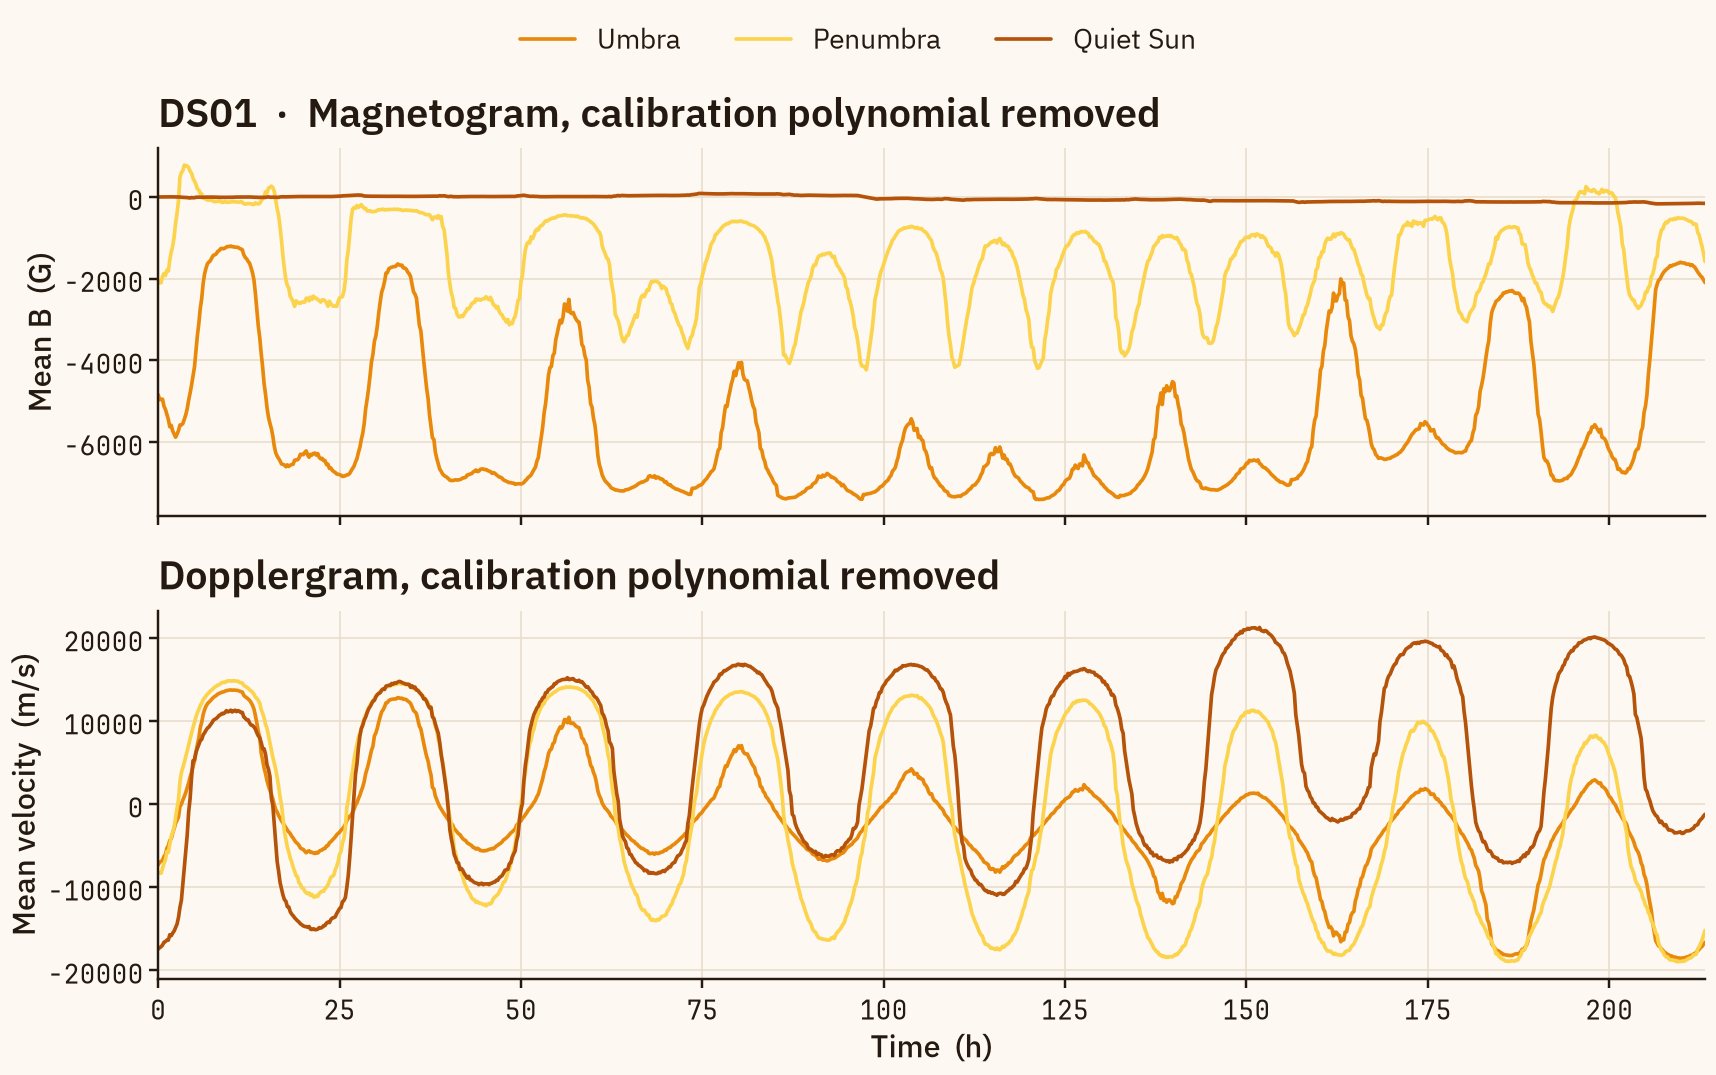

In [ ]:
# DS01, polynomial removed — reconstructed field above, reconstructed velocity below
fig, (ax_mag, ax_dop) = plt.subplots(2, 1, figsize=FIGSIZE_STACK, sharex=True)

for label, suffix in REGIONS:
    colour = REGION_COLOR[label]
    ax_mag.plot(time_h, rempol[f'mean_mag_{suffix}'], color=colour, lw=LW_SERIES, label=label)
    ax_dop.plot(time_h, rempol[f'mean_dop_{suffix}'], color=colour, lw=LW_SERIES, label=label)

ax_mag.set_ylabel('Mean B  (G)')
ax_mag.set_title(f'{DATASET}  ·  Magnetogram, calibration polynomial removed', loc='left')
ax_dop.set_ylabel('Mean velocity  (m/s)')
ax_dop.set_xlabel('Time  (h)')
ax_dop.set_title('Dopplergram, calibration polynomial removed', loc='left')

for ax in (ax_mag, ax_dop):
    ax.set_xlim(time_h[0], time_h[-1])


mono_ticks(ax_mag, ax_dop)
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.legend(*ax_dop.get_legend_handles_labels(), ncol=4,
           loc='upper center', bbox_to_anchor=(0.5, 1.0), frameon=False)
save_fig(fig, 'ds01_rempol_time_series')
plt.show()

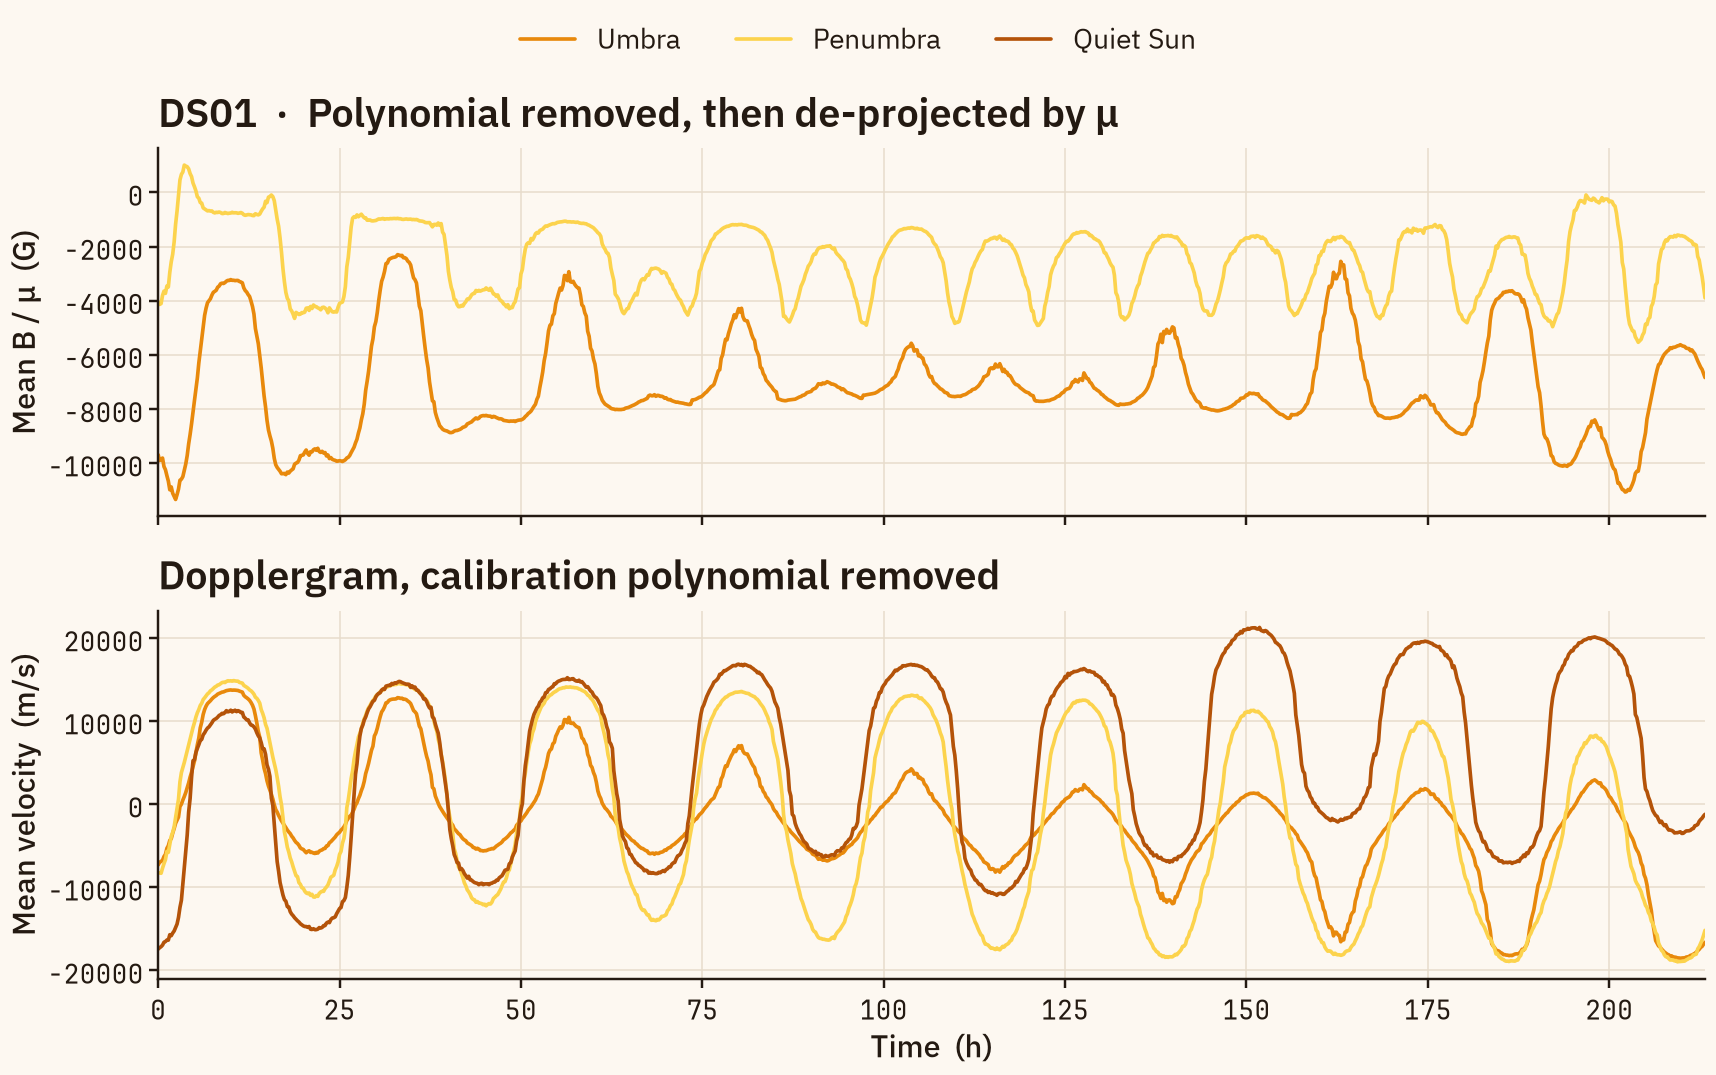

original      B/μ ÷ B :  t=0   2.00   mid   1.03   end   2.15    (1/μ = 2.01, 1.03, 2.15)
reconstructed B/μ ÷ B :  t=0   2.00   mid   1.03   end   3.26    (1/μ = 2.01, 1.03, 2.15)


In [ ]:
# DS01, polynomial removed AND de-projected by μ — B_recon/μ above, velocity below
fig, (ax_mag, ax_dop) = plt.subplots(2, 1, figsize=FIGSIZE_STACK, sharex=True)

for label, suffix in REGIONS:
    colour = REGION_COLOR[label]
    if suffix != 'quiet':                       # the quiet Sun has no μ series
        ax_mag.plot(time_h, rempol[f'mean_magmu_{suffix}'],
                    color=colour, lw=LW_SERIES, label=label)
    ax_dop.plot(time_h, rempol[f'mean_dop_{suffix}'], color=colour, lw=LW_SERIES, label=label)

ax_mag.set_ylabel('Mean B / μ  (G)')
ax_mag.set_title(f' Polynomial removed, then de-projected by μ', loc='left')
ax_dop.set_ylabel('Mean velocity  (m/s)')
ax_dop.set_xlabel('Time  (h)')
ax_dop.set_title('Dopplergram, calibration polynomial removed', loc='left')

for ax in (ax_mag, ax_dop):
    ax.set_xlim(time_h[0], time_h[-1])

mono_ticks(ax_mag, ax_dop)
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.legend(*ax_dop.get_legend_handles_labels(), ncol=4,
           loc='upper center', bbox_to_anchor=(0.5, 1.0), frameon=False)
save_fig(fig, 'ds01_rempol_mag_over_mu')
plt.show()

# μ is geometry — the same divisor applies whichever field cube it divides. So the B/μ-to-B
# ratio should trace 1/μ for the reconstruction just as it does for the original.
for name, mag, magmu in (('original     ', metrics['mean_mag_umb'], metrics['mean_magmu_umb']),
                         ('reconstructed', rempol['mean_mag_umb'],  rempol['mean_magmu_umb'])):
    ratio = magmu / mag
    print(f'{name} B/μ ÷ B :  t=0 {ratio[0]:6.2f}   mid {ratio[len(ratio)//2]:6.2f}   '
          f'end {ratio[-1]:6.2f}    (1/μ = {1/metrics["mu_umb"][0]:.2f}, '
          f'{1/metrics["mu_umb"][len(ratio)//2]:.2f}, {1/metrics["mu_umb"][-1]:.2f})')

## Spectra

`spectra.psd_spectrum` does the estimation; only the drawing is here. `xlim` stops at 0.1 mHz —
Nyquist is 0.69 mHz, but everything of interest sits far below it.

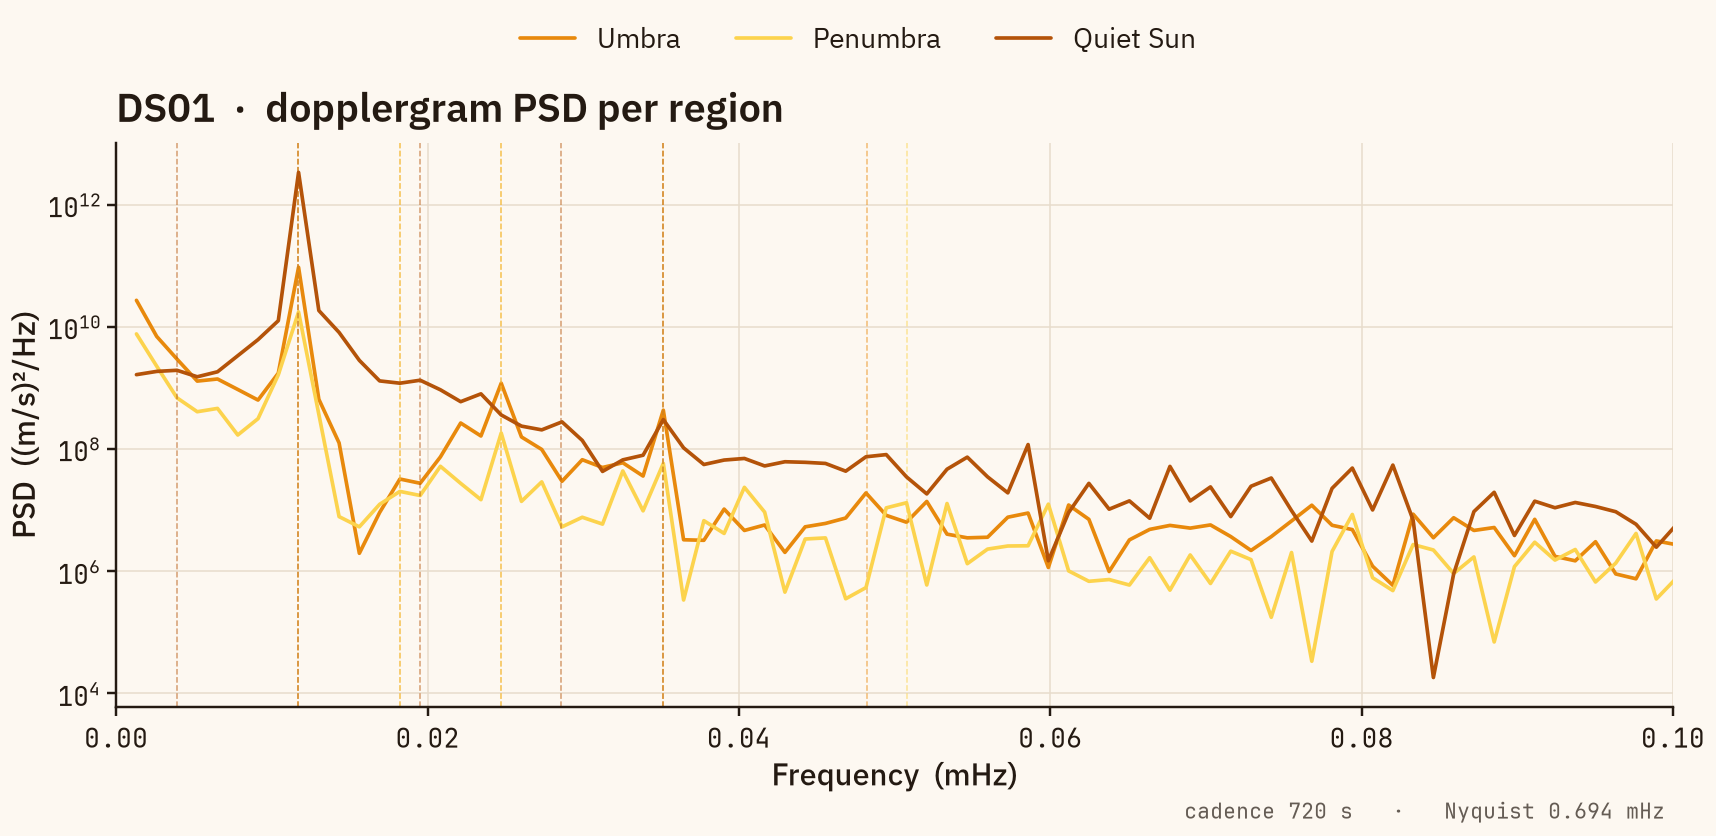

In [ ]:
# DS01 — power spectral density, four regions on one axis
XLIM = (0, 0.1)

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
lo, hi = np.inf, -np.inf

for label, suffix in REGIONS:
    colour = REGION_COLOR[label]
    freq, power = spectra.psd_spectrum(metrics[f'mean_dop_{suffix}'], cadence_s)
    ax.plot(freq, power, color=colour, lw=LW_SERIES, label=label)

    # The whole spectrum is drawn but only part of it is shown, so the y-range has to
    # come from the visible window — otherwise autoscale reserves room for data off-screen.
    shown = power[(freq >= XLIM[0]) & (freq <= XLIM[1])]
    if shown.size:
        lo, hi = min(lo, shown.min()), max(hi, shown.max())

    # mark the peaks, but only the ones inside the window being shown
    peaks = spectra.spectral_peaks(freq, power)
    for _, row in peaks.iterrows():
        if XLIM[0] <= row['freq_mhz'] <= XLIM[1]:
            ax.axvline(row['freq_mhz'], color=colour, lw=LW_GRID, ls='--', alpha=0.55)

ax.set_yscale('log')
ax.set_xlim(*XLIM)
ax.set_ylim(lo / 3, hi * 3)
ax.set_xlabel('Frequency  (mHz)')
ax.set_ylabel('PSD  ((m/s)²/Hz)')
ax.set_title(f'{DATASET}  ·  dopplergram PSD per region', loc='left')
ax.text(0.995, -0.16, f'cadence {cadence_s:.0f} s   ·   Nyquist {1e3 / (2 * cadence_s):.3f} mHz',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=FS_ANNOT, family='monospace', color=C_INK, alpha=0.7)

mono_ticks(ax)
fig.tight_layout(rect=(0, 0, 1, 0.93))

# Legend in its own band above the title, clear of the data.
fig.legend(*ax.get_legend_handles_labels(), ncol=4,
           loc='upper center', bbox_to_anchor=(0.5, 1.0), frameon=False)
save_fig(fig, 'ds01_psd_regions')
plt.show()

### Does the field oscillate with the velocity?

Umbra only, each curve normalised to its own peak — the only way to put (m/s)²/Hz and G²/Hz on
one axis. The magnetogram is the *residual*, not the raw series, because the raw one's slow
trend dominates its own spectrum and buries whatever else is there.

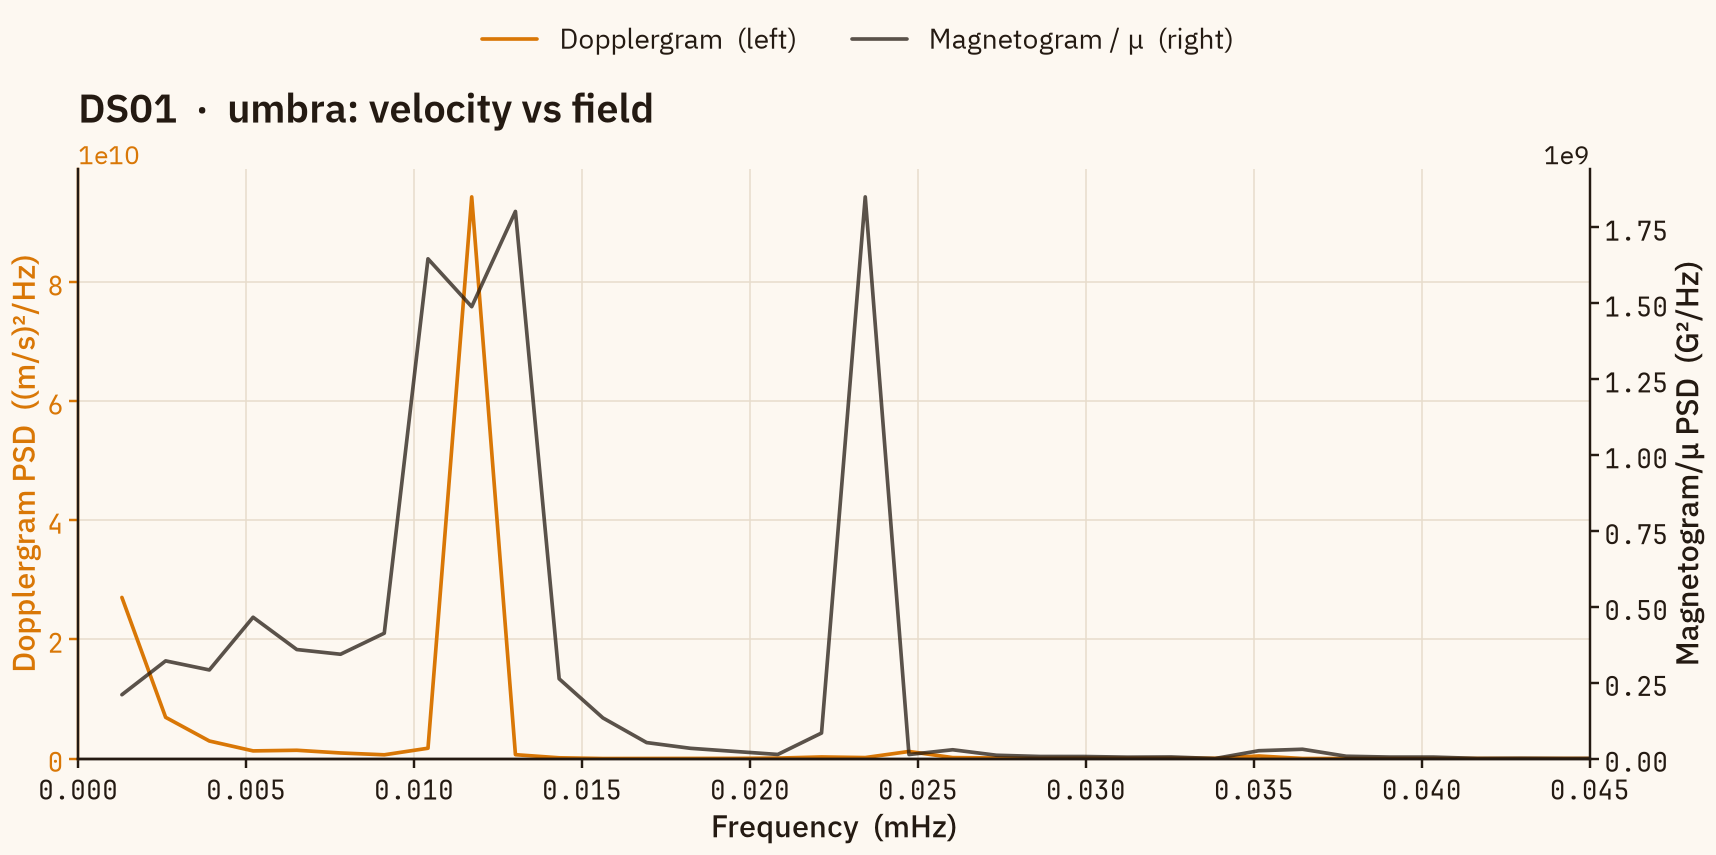


Dopplergram
  rank  freq (mHz)  period (min)  period (h)  relative
     1      0.0117        1422.7       23.71     1.000
     2      0.0247         673.9       11.23     0.013
     3      0.0351         474.2        7.90     0.004
     4      0.0182         914.6       15.24     0.000
     5      0.0482         346.1        5.77     0.000

Magnetogram / μ
  rank  freq (mHz)  period (min)  period (h)  relative
     1      0.0234         711.3       11.85     1.000
     2      0.0130        1280.4       21.34     0.974
     3      0.0052        3201.0       53.35     0.252
     4      0.0364         457.3        7.62     0.017
     5      0.0638         261.3        4.36     0.002


In [ ]:
# DS01 — umbra: dopplergram vs magnetogram/μ, each on its own axis
XLIM = (0, 0.045)          # everything above this is flat; the window is the story

freq_dop, power_dop = spectra.psd_spectrum(metrics['mean_dop_umb'], cadence_s)
freq_mag, power_mag = spectra.psd_spectrum(metrics['mean_magmu_umb'], cadence_s)

fig, ax_dop = plt.subplots(figsize=FIGSIZE_WIDE)
ax_mag = ax_dop.twinx()

# Two y-scales, so the height where the curves cross is set by the scaling, not by the
# data. Read each curve against its own axis and compare peak *positions*, not heights.
ax_dop.plot(freq_dop, power_dop, color=C_ACCENT, lw=LW_SERIES,
            label='Dopplergram  (left)')
ax_mag.plot(freq_mag, power_mag, color=C_INK, lw=LW_SERIES, alpha=0.75,
            label='Magnetogram / μ  (right)')

ax_dop.set_ylabel('Dopplergram PSD  ((m/s)²/Hz)', color=C_ACCENT)
ax_mag.set_ylabel('Magnetogram/μ PSD  (G²/Hz)', color=C_INK)
ax_dop.tick_params(axis='y', colors=C_ACCENT)
ax_mag.tick_params(axis='y', colors=C_INK)
ax_dop.spines['left'].set_color(C_ACCENT)
ax_mag.spines['right'].set_visible(True)
ax_mag.spines['right'].set_color(C_INK)
ax_mag.grid(False)                      # one grid only, from the left axis

ax_dop.set_xlim(*XLIM)
ax_dop.set_ylim(bottom=0)
ax_mag.set_ylim(bottom=0)
ax_dop.set_xlabel('Frequency  (mHz)')
ax_dop.set_title(f'{DATASET}  ·  umbra: velocity vs field', loc='left')

mono_ticks(ax_dop, ax_mag)
fig.tight_layout(rect=(0, 0, 1, 0.93))

handles = ax_dop.get_lines() + ax_mag.get_lines()
fig.legend(handles, [h.get_label() for h in handles], ncol=2,
           loc='upper center', bbox_to_anchor=(0.5, 1.0), frameon=False)
save_fig(fig, 'ds01_psd_compare_umbra')
plt.show()

for name, freq, power in (('Dopplergram', freq_dop, power_dop),
                          ('Magnetogram / μ', freq_mag, power_mag)):
    peaks = spectra.spectral_peaks(freq, power)
    print(f'\n{name}')
    if peaks.empty:
        print('  no peaks above the threshold')
        continue
    print(f'  {"rank":>4} {"freq (mHz)":>11} {"period (min)":>13} {"period (h)":>11} {"relative":>9}')
    for _, r in peaks.iterrows():
        print(f'  {int(r["rank"]):>4} {r["freq_mhz"]:>11.4f} {r["period_min"]:>13.1f} '
              f'{r["period_min"] / 60:>11.2f} {r["relative"]:>9.3f}')

### Amplitude in the 16–36 h band

`spectra.band_amplitude` — Hann window, zero-padded, coherent-gain corrected, so the number
comes back in m/s. `cycles` is how many periods the 213 h window actually covers; below about
1.5 the amplitude is barely constrained.

In [ ]:
# DS01 — semi-amplitude of the dominant peak in the 16–36 h band, per region
print(f'{"region":<12} {"amplitude":>12} {"period":>10} {"cycles":>9}')
print('─' * 46)
for label, suffix in REGIONS:
    result = spectra.band_amplitude(time_h, metrics[f'mean_dop_{suffix}'])
    print(f'{label:<12} {result["amplitude"]:>10.1f} m/s '
          f'{result["period_h"]:>8.2f} h {result["n_cycles"]:>9.1f}')

region          amplitude     period    cycles
──────────────────────────────────────────────
Umbra             478.2 m/s    23.71 h       9.0
Penumbra          166.3 m/s    23.39 h       9.1
Quiet Sun        2993.4 m/s    23.71 h       9.0


---

# Simulation — SDO/Sun relative line-of-sight velocity

Latitude and depth are *magnitudes*, not identities, so these two figures sample `CMAP_AMBER`
rather than stepping through the four series colours.

In [ ]:
import numpy as np

# --- constants (from the Desmos graph, g dropped / set to 1) ---
w_sdo = 2 * np.pi / (1436 * 60)                    # SDO orbital angular rate [rad/s]
R_sdo = 6571 * 1000 + 35756 * 1000                 # SDO orbital radius [m]
R_sun = 695508 * 1000                              # solar radius [m]
d = 1.495979e11                                    # Earth-Sun distance [m]
T_hours = 324                                      # simulated duration [hours]


def w_sun(phi_rad):
    """Differential rotation rate at latitude phi, converted deg/day -> rad/s."""
    deg_per_day = 14.713 - 2.396 * np.sin(phi_rad) ** 2 - 1.787 * np.sin(phi_rad) ** 4
    return (np.pi / 180 / 86400) * deg_per_day


def relative_speed(phi_deg, t):
    """|du/dt| at latitude phi_deg (degrees) over time array t (seconds)."""
    phi = np.radians(phi_deg)
    ws = w_sun(phi)
    cphi = np.cos(phi)
    alpha_deg = 26
    cos_alpha = np.cos(np.radians(alpha_deg))
    sin_alpha = np.sin(np.radians(alpha_deg))

    dux_dt = -R_sdo * w_sdo * np.sin(w_sdo * t) * cos_alpha - R_sun * cphi * ws * np.sin(ws * t)
    duy_dt = R_sdo * w_sdo * np.cos(w_sdo * t) + R_sun * cphi * ws * np.cos(ws * t)
    duz_dt = -R_sdo * w_sdo * np.sin(w_sdo * t) * sin_alpha

    return np.sqrt(dux_dt ** 2 + duy_dt ** 2 + duz_dt ** 2)

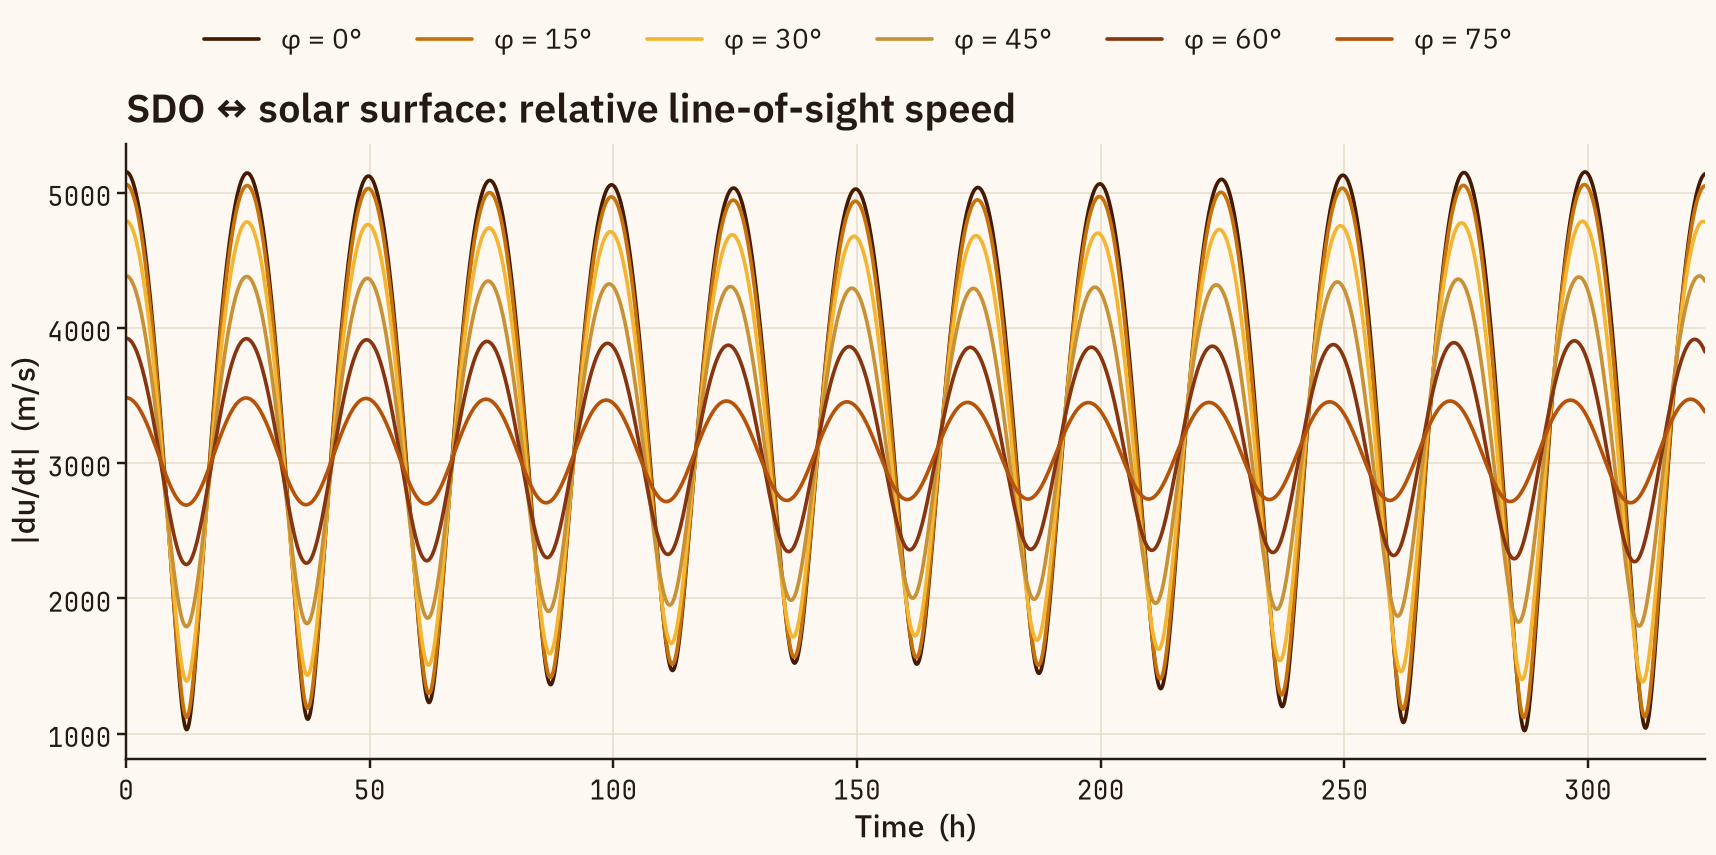

In [ ]:
# Relative LOS speed vs time, one curve per latitude
t = np.linspace(0, T_hours * 3600, 5000)
t_hours = t / 3600
phi_values_deg = [0, 15, 30, 45, 60, 75]

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
for i, phi_deg in enumerate(phi_values_deg):
    colour = CMAP_AMBER(i / (len(phi_values_deg) - 1))
    ax.plot(t_hours, relative_speed(phi_deg, t), color=colour, lw=LW_SERIES,
            label=f'φ = {phi_deg}°')

ax.set_xlim(t_hours[0], t_hours[-1])
ax.set_xlabel('Time  (h)')
ax.set_ylabel('|du/dt|  (m/s)')
ax.set_title('SDO ↔ solar surface: relative line-of-sight speed', loc='left')

mono_ticks(ax)
fig.tight_layout(rect=(0, 0, 1, 0.93))

# Legend in its own band above the title, clear of the data.
fig.legend(*ax.get_legend_handles_labels(), ncol=6,
           loc='upper center', bbox_to_anchor=(0.5, 1.0), frameon=False)
save_fig(fig, 'sim_relative_velocity')
plt.show()

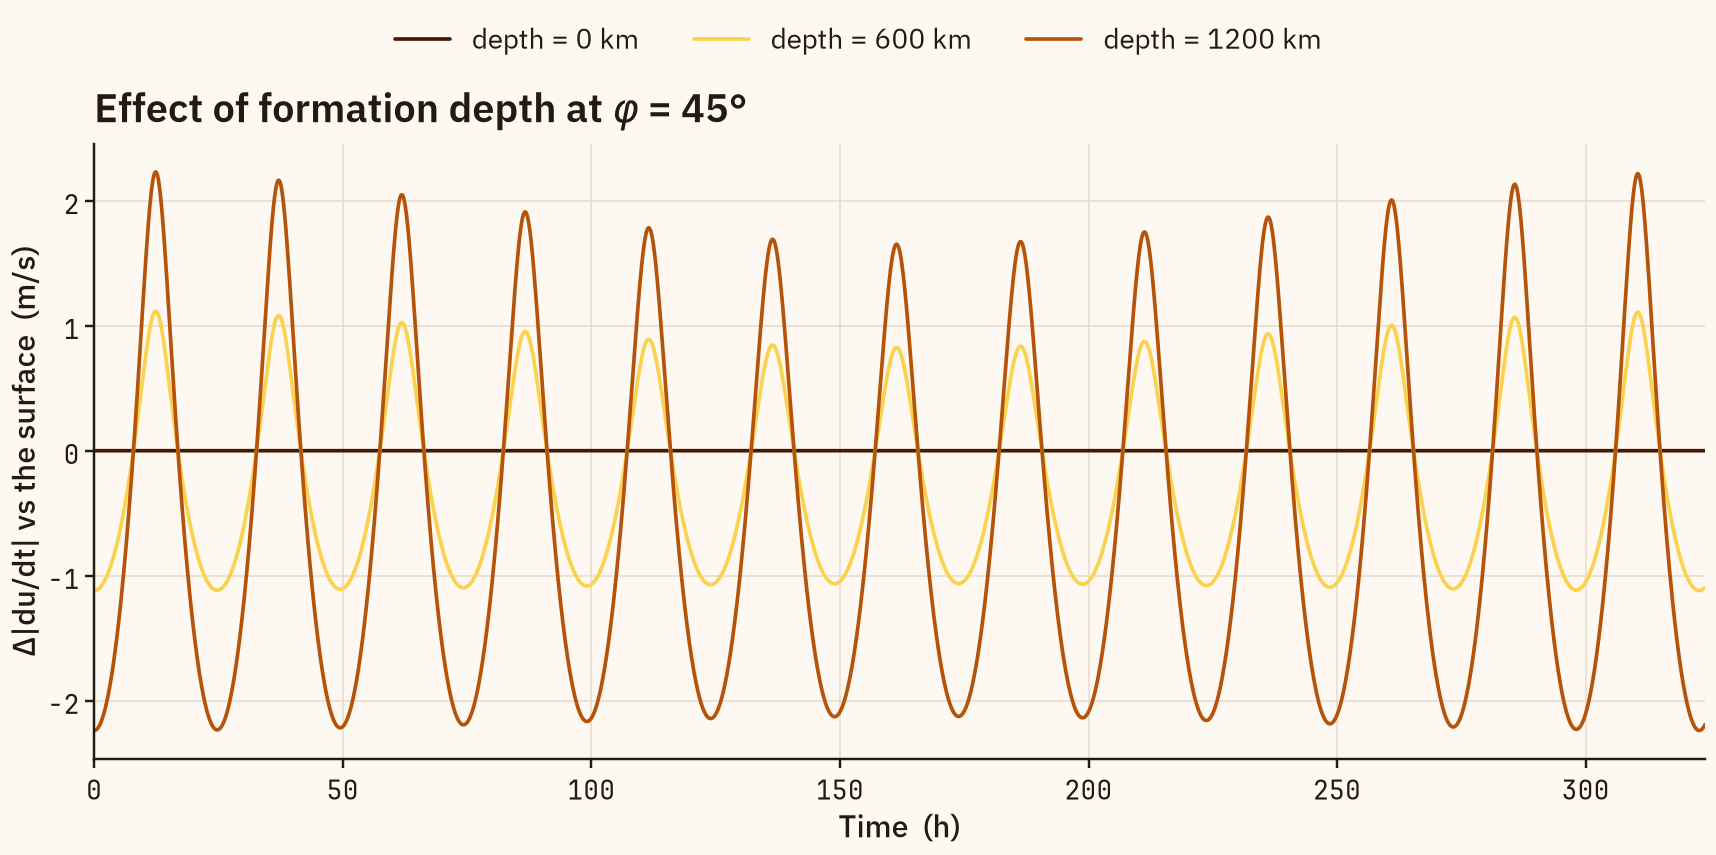

In [ ]:
# How much the speed changes if the signal forms some depth below the surface
phi = 45
depths_m = [0, 600 * 1000, 1200 * 1000]

t = np.linspace(0, T_hours * 3600, 5000)
t_hours = t / 3600
v_surface = relative_speed(phi, t)

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
for i, depth in enumerate(depths_m):
    R_sun_original = R_sun
    R_sun -= depth
    v = relative_speed(phi, t)
    R_sun = R_sun_original
    colour = CMAP_AMBER(i / (len(depths_m) - 1))
    ax.plot(t_hours, v - v_surface, color=colour, lw=LW_SERIES,
            label=f'depth = {depth / 1000:.0f} km')

ax.set_xlim(t_hours[0], t_hours[-1])
ax.set_xlabel('Time  (h)')
ax.set_ylabel('Δ|du/dt| vs the surface  (m/s)')
ax.set_title(fr'Effect of formation depth at $\varphi$ = {phi}°', loc='left')

mono_ticks(ax)
fig.tight_layout(rect=(0, 0, 1, 0.93))

# Legend in its own band above the title, clear of the data.
fig.legend(*ax.get_legend_handles_labels(), ncol=3,
           loc='upper center', bbox_to_anchor=(0.5, 1.0), frameon=False)
save_fig(fig, 'sim_depth_comparison')
plt.show()

---

# `hmi.coefficients` — the Doppler calibration cubics

Needs network: the next cell queries JSOC. Nothing in the DS01 section depends on it.

In [ ]:
import drms

client = drms.Client()

si = client.info('hmi.coefficients')
print(si.primekeys)
print(si.keywords.index.tolist())

query = client.query('hmi.coefficients[2017.08.03_TAI/8d]', key=si.keywords.index.tolist())
query

['T_REC']
['T_REC', 'T_START', 'T_STOP', 'DATAUSED', 'CAL_FSN', 'DATE', 'NDATA', 'COEFF0', 'COEFF1', 'COEFF2', 'COEFF3']


,T_REC,T_START,T_STOP,DATAUSED,CAL_FSN,DATE,NDATA,COEFF0,COEFF1,COEFF2,COEFF3
0,2017.08.03_06:45:00_TAI,2017.08.02_18:45:00_TAI,2017.08.03_18:45:00_TAI,hmi.V_45s_nrt[2017.08.02_18:45:00_TAI-2017.08....,121048472,2017-08-06T16:45:34Z,1881,188.0067,0.006999,-0.000007,-8.414051e-10
1,2017.08.03_18:45:00_TAI,2017.08.03_06:45:00_TAI,2017.08.04_06:45:00_TAI,hmi.V_45s_nrt[2017.08.03_06:45:00_TAI-2017.08....,121048472,2017-08-07T16:50:48Z,1887,187.5741,0.006670,-0.000007,-8.199870e-10
2,2017.08.04_06:45:00_TAI,2017.08.03_18:45:00_TAI,2017.08.04_18:45:00_TAI,hmi.V_45s_nrt[2017.08.03_18:45:00_TAI-2017.08....,121048472,2017-08-07T16:51:18Z,1921,187.2737,0.006637,-0.000007,-8.109732e-10
3,2017.08.04_18:45:00_TAI,2017.08.04_06:45:00_TAI,2017.08.05_06:45:00_TAI,hmi.V_45s_nrt[2017.08.04_06:45:00_TAI-2017.08....,121048472,2017-08-08T16:54:59Z,1921,187.5247,0.006753,-0.000007,-8.256654e-10
4,2017.08.05_06:45:00_TAI,2017.08.04_18:45:00_TAI,2017.08.05_18:45:00_TAI,hmi.V_45s_nrt[2017.08.04_18:45:00_TAI-2017.08....,121048472,2017-08-08T16:55:28Z,1921,187.4194,0.006948,-0.000007,-8.255739e-10
5,2017.08.05_18:45:00_TAI,2017.08.05_06:45:00_TAI,2017.08.06_06:45:00_TAI,hmi.V_45s_nrt[2017.08.05_06:45:00_TAI-2017.08....,121048472,2017-08-09T16:59:22Z,1920,187.1973,0.006837,-0.000007,-8.221256e-10
6,2017.08.06_06:45:00_TAI,2017.08.05_18:45:00_TAI,2017.08.06_18:45:00_TAI,hmi.V_45s_nrt[2017.08.05_18:45:00_TAI-2017.08....,121048472,2017-08-09T16:59:51Z,1919,187.4114,0.006596,-0.000007,-8.218669e-10
7,2017.08.06_18:45:00_TAI,2017.08.06_06:45:00_TAI,2017.08.07_06:45:00_TAI,hmi.V_45s_nrt[2017.08.06_06:45:00_TAI-2017.08....,121048472,2017-08-10T17:02:21Z,1920,188.3779,0.007331,-0.000007,-8.708458e-10
8,2017.08.07_06:45:00_TAI,2017.08.06_18:45:00_TAI,2017.08.07_18:45:00_TAI,hmi.V_45s_nrt[2017.08.06_18:45:00_TAI-2017.08....,121048472,2017-08-10T17:02:31Z,1921,189.6946,0.006326,-0.000007,-8.038637e-10
9,2017.08.07_18:45:00_TAI,2017.08.07_06:45:00_TAI,2017.08.08_06:45:00_TAI,hmi.V_45s_nrt[2017.08.07_06:45:00_TAI-2017.08....,121048472,2017-08-11T17:06:58Z,1921,190.8341,0.007165,-0.000006,-8.414437e-10


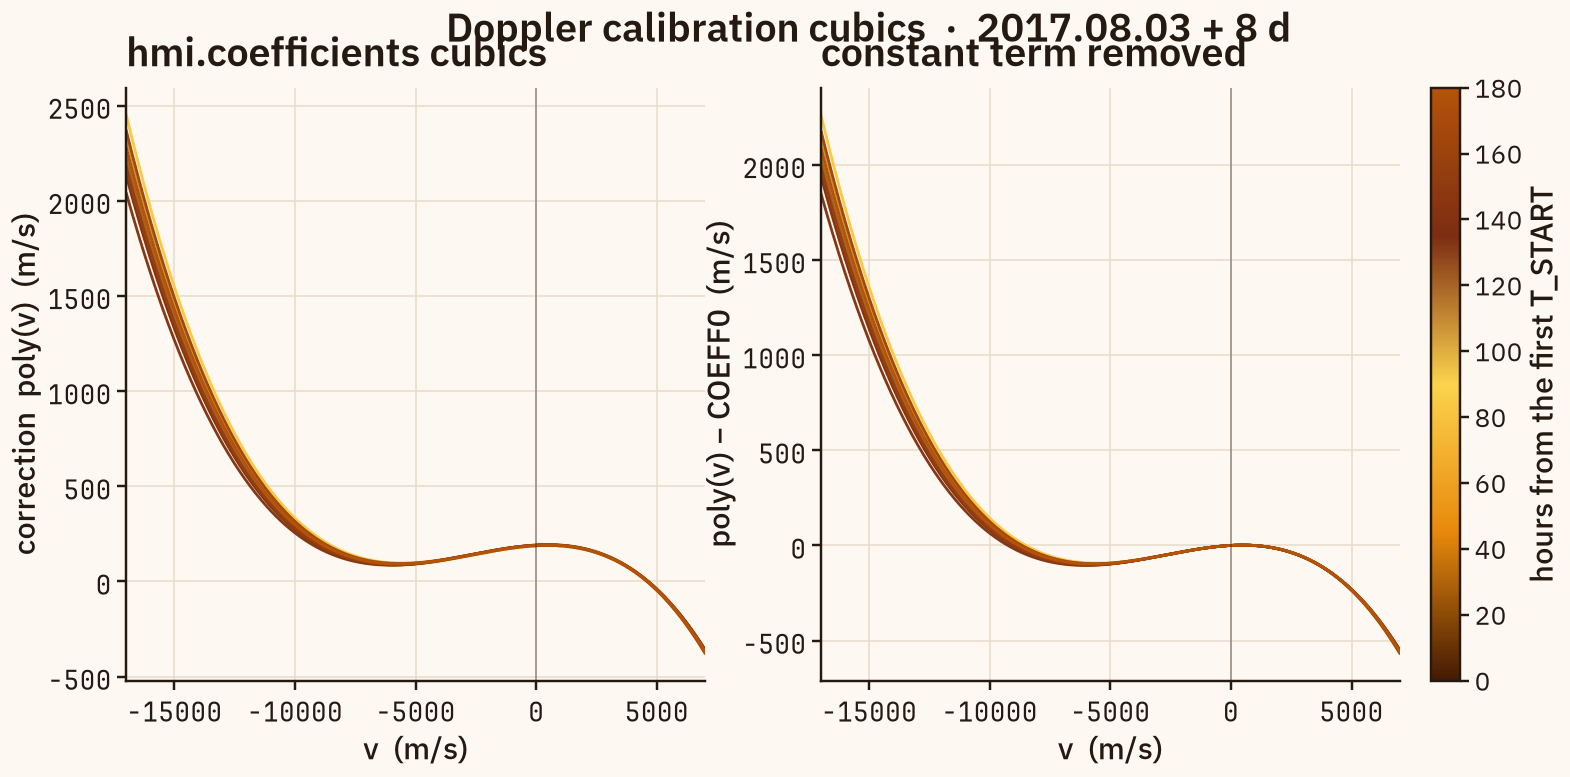

COEFF0 spread over the 8 days: 187.1973 .. 191.2282 m/s
poly(-17000) .. poly(7000) for row 0: 2312.1036 .. -372.1789 m/s
so across that range each cubic moves by ~2684.282 m/s, against a 4.012 m/s spread between windows


In [ ]:
# The 16 cubics themselves. Hours-since-the-first-window is a magnitude, so it gets the ramp.
BIN_HOURS = 12.0          # the hmi.coefficients window length

v_axis = np.linspace(-17000.0, 7000.0, 4001)
n_windows = len(query)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(18, 7))

for i, r in query.iterrows():
    y = np.polyval([r.COEFF3, r.COEFF2, r.COEFF1, r.COEFF0], v_axis)
    colour = CMAP_AMBER(i / (n_windows - 1))
    ax0.plot(v_axis, y, lw=1.8, color=colour)
    ax1.plot(v_axis, y - r.COEFF0, lw=1.8, color=colour)

ax0.set_ylabel('correction  poly(v)  (m/s)')
ax0.set_title('hmi.coefficients cubics', loc='left')
ax1.set_ylabel('poly(v) − COEFF0  (m/s)')
ax1.set_title('constant term removed', loc='left')

for ax in (ax0, ax1):
    ax.set_xlabel('v  (m/s)')
    ax.set_xlim(v_axis[0], v_axis[-1])
    ax.axvline(0, color=C_INK, lw=LW_GRID, alpha=0.45)
    mono_ticks(ax)

sm = plt.cm.ScalarMappable(cmap=CMAP_AMBER,
                           norm=plt.Normalize(0, (n_windows - 1) * BIN_HOURS))
cbar = fig.colorbar(sm, ax=[ax0, ax1], pad=0.02)
cbar.set_label('hours from the first T_START', size=FS_LABEL)
cbar.ax.tick_params(labelsize=FS_TICK)

fig.suptitle('Doppler calibration cubics  ·  2017.08.03 + 8 d')
save_fig(fig, 'hmi_coefficients_polynomials')
plt.show()

edges = np.polyval([query.COEFF3, query.COEFF2, query.COEFF1, query.COEFF0], -100.0)
print(f'COEFF0 spread over the 8 days: {query.COEFF0.min():.4f} .. {query.COEFF0.max():.4f} m/s')
row0 = query.loc[0, ['COEFF3', 'COEFF2', 'COEFF1', 'COEFF0']].to_numpy(float)
print(f'poly({v_axis[0]:.0f}) .. poly({v_axis[-1]:.0f}) for row 0: '
      f'{np.polyval(row0, v_axis[0]):.4f} .. {np.polyval(row0, v_axis[-1]):.4f} m/s')
print(f'so across that range each cubic moves by ~{np.ptp(np.polyval(row0, v_axis)):.3f} m/s, '
      f'against a {np.ptp(edges):.3f} m/s spread between windows')

---

# Fitted 24 h amplitude vs the Wilson depression

The Löptien et al. sunspots have Wilson depressions measured independently with Hinode, by two
methods: `z_div` from the divergence-free condition on **B**, and `z_press` from the
magnetohydrostatic pressure balance. `config.LOPTIEN_TABLE` transcribes them, plus one Romero
(2020) point for NOAA 13131 at 800 km.

Against those we put the amplitude of the 24 h sinusoid fitted to each region's **absolute**
umbral Doppler signal (`oscillation.fit_diurnal`, period held at 24 h so the fit is one exact
least-squares solve).

The quiet-Sun-subtracted fit is still computed and cached, as the instrumental control: if most
of the amplitude were common to the whole box rather than umbral — a residual of the diurnal
`v_SDO` correction — the two would disagree badly. They do not, so only the absolute series is
drawn.

**These are the plain series — no polynomial removal.** That matters: every `metrics.csv` on
disk, and `diurnal_fits.csv` with it, was written by a run with the reconstruction on, which
inflates the fitted amplitudes by roughly 5×. The plain fit for NOAA 11536 is 214.2 ± 2.6 m/s,
the value `config.py` documents; the reconstructed one is 1194.5. So the cell below rebuilds the
fits from the cubes and caches them to `diurnal_fits_plain.csv`.

With six points, the correlation and the line describe this sample. They are not evidence of a
relationship.

In [ ]:
"""Plain (no-reconstruction) 24 h fits per Löptien region, cached. Heavy once."""

RECOMPUTE_FITS = False           # True forces a rebuild even if the cache exists
FITS_CSV = config.PROCESSED_DIR / 'diurnal_fits_plain.csv'

if RECOMPUTE_FITS or not FITS_CSV.exists():
    import gc

    from src import oscillation
    from src.analysis import compute_metrics
    from src.loaders import load_noaa_region

    # 11117 appears twice in the Löptien table — one continuous passage, two 24 h windows —
    # so group by processed region and load each region's cubes only once.
    wanted = {}
    for noaa, date, theta, area_mm2, b_av, z_div, z_press in config.LOPTIEN_TABLE:
        window = config.FIT_WINDOWS.get((noaa, date))
        if window is None:
            continue
        hits = [p for p in config.PROCESSED_DIR.glob(f'NOAA_{noaa}_*')
                if (p / 'region_01_continuum_cube.fits').exists()]
        if not hits:
            print(f'  skipped  NOAA {noaa} {date}: no processed cube')
            continue
        wanted.setdefault(hits[0], []).append(
            dict(noaa=noaa, date=date, window=window, theta_deg=theta, area_mm2=area_mm2,
                 b_av=b_av, z_div_km=z_div, z_press_km=z_press))

    # One region in memory at a time: 11106's cubes alone are 769 MB each, and only two
    # 1-D series survive each iteration.
    fit_records = []
    for region_dir, entries in sorted(wanted.items()):
        params = config.params_for(region_dir)
        d = load_noaa_region(region_dir, raw_dir=config.RAW_DIR / region_dir.name,
                             **config.loader_kwargs(params))
        m = compute_metrics(d)
        time_h = np.asarray(d['time_h'], float)
        v_abs  = np.asarray(m['mean_dop_umb'], float)
        v_rel  = v_abs - np.asarray(m['mean_dop_quiet'], float)
        umbra_px = float(d['umbra'].sum(axis=(1, 2)).mean())
        del d, m
        gc.collect()

        for e in entries:
            # One shared mask for both fits — that is what makes the two amplitude columns
            # a real control rather than two loosely related numbers.
            shared = np.isfinite(v_abs) & np.isfinite(v_rel)
            fa = oscillation.fit_diurnal(time_h, v_abs, window=e['window'],
                                         period_h=config.FIT_PERIOD_H, mask=shared)
            fr = oscillation.fit_diurnal(time_h, v_rel, window=e['window'],
                                         period_h=config.FIT_PERIOD_H, mask=shared)
            fit_records.append(dict(
                label=f'NOAA {e["noaa"]} {e["date"]}', noaa=e['noaa'], date=e['date'],
                region=region_dir.name, period_h=config.FIT_PERIOD_H,
                window_start_h=e['window'][0], window_end_h=e['window'][1], n_points=fa['n'],
                theta_deg=e['theta_deg'], area_mm2=e['area_mm2'], b_av_G=e['b_av'],
                z_div_km=e['z_div_km'], z_press_km=e['z_press_km'], umbra_px=umbra_px,
                **{f'{k}_abs': fa[k] for k in ('intercept', 'amplitude', 'sigma_intercept',
                                               'sigma_amplitude', 't_max', 'rms_residual')},
                **{f'{k}_rel': fr[k] for k in ('intercept', 'amplitude', 'sigma_intercept',
                                               'sigma_amplitude', 't_max', 'rms_residual')}))
        del time_h, v_abs, v_rel
        gc.collect()
        print(f'  fitted {region_dir.name}')

    pd.DataFrame(fit_records).to_csv(FITS_CSV, index=False, float_format='%.4f')
    print(f'plain fits written → {FITS_CSV}  ({len(fit_records)} rows)')
else:
    print(f'using cached {FITS_CSV.name} — set RECOMPUTE_FITS = True to rebuild')

fits = pd.read_csv(FITS_CSV)

print(f'\n{"region":24s}{"amplitude, absolute":>22}{"amplitude − quiet":>22}'
      f'{"z_div":>8}{"z_press":>9}')
print('─' * 85)
for _, r in fits.iterrows():
    print(f'{r["label"]:24s}{r["amplitude_abs"]:14.1f} ± {r["sigma_amplitude_abs"]:5.1f}'
          f'{r["amplitude_rel"]:14.1f} ± {r["sigma_amplitude_rel"]:5.1f}'
          f'{r["z_div_km"]:8.0f}{r["z_press_km"]:9.0f}')

using cached diurnal_fits_plain.csv — set RECOMPUTE_FITS = True to rebuild

region                     amplitude, absolute     amplitude − quiet   z_div  z_press
─────────────────────────────────────────────────────────────────────────────────────
NOAA 11106 2010-09-16            343.5 ±   4.0         339.9 ±   3.7     636      381
NOAA 11117 2010-10-27            303.0 ±   5.0         313.9 ±   5.0     561      291
NOAA 11117 2010-10-28            357.0 ±   6.7         363.7 ±   6.6     625      313
NOAA 11363 2011-12-06            180.1 ±   2.2         178.7 ±   1.3     524      326
NOAA 11536 2012-07-31            214.2 ±   2.6         218.7 ±   2.3     577      346
NOAA 13131 2022-10-29            275.1 ±   2.5         249.5 ±   3.0     800      800


In [ ]:
fits = fits.iloc[:-1]

In [ ]:
# Cross-region figures live beside the other consolidated outputs, not in DS01's folder.
LOPTIEN_PLOTS_DIR = config.PROCESSED_DIR / 'plots'

def save_loptien_fig(fig, name):
    """Write `name`.png into LOPTIEN_PLOTS_DIR. No-op unless SAVE."""
    if not SAVE:
        return
    LOPTIEN_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
    out = LOPTIEN_PLOTS_DIR / f'{name}.png'
    fig.savefig(out, dpi=DPI_SAVE, bbox_inches='tight', facecolor=C_FIG_BG)
    print(f'saved → {out}')


# Only the absolute umbral velocity is plotted. The quiet-Sun-subtracted series stays in
# the cached CSV as the instrumental control: it differs from the absolute one by at most
# 3.6% across the five Löptien regions (9.3% for 13131), so the oscillation is umbral and
# drawing the second series added a marker and no information.
FIT_SERIES = [('abs', C_ACCENT, 'o', 'Umbra, absolute')]

DEPTH_LABEL = {'z_div_km':   r'$z_{W,\mathrm{div}}$',
               'z_press_km': r'$z_{W,\mathrm{press}}$'}


def linear_fit(x, y):
    """Least-squares y = m x + b, with 1-sigma errors and Pearson r. None if too few points."""
    good = np.isfinite(x) & np.isfinite(y)
    if good.sum() < 3:
        return None
    (m, b), cov = np.polyfit(x[good], y[good], 1, cov=True)
    return dict(slope=m, intercept=b,
                sigma_slope=float(np.sqrt(cov[0, 0])), sigma_intercept=float(np.sqrt(cov[1, 1])),
                r=float(np.corrcoef(x[good], y[good])[0, 1]), n=int(good.sum()))

### Do the fitted curves actually sit on the data?

One panel per fitted window: the whole record faint, the 24 h window shaded, the fitted sinusoid
drawn over the stretch it was fitted to. A fit that latched onto a download gap, a segmentation
step or a slow trend still produces a perfectly respectable-looking amplitude, and the only way
to catch it is to look at the curve on the points — so this comes *before* the two scatters.

The series drawn is the quiet-Sun-subtracted one (`series_key='fit_rel'`), the control described
above.

`comparison.plot_diurnal_fits(fit_rows, series_key='fit_rel')` draws exactly this figure, but in
its own greys and crimson and on a 2-column layout sized 6.5 × 3.2 in per panel. As everywhere
else in this notebook the matplotlib is in the cell instead, so the six windows are a 3 × 2 grid
in 12 × 8 in, in the deck's colours. The file it writes,
`plots/diurnal_fit_rel.png`, keeps the same name the function uses.

Two things the panels need that `diurnal_fits_plain.csv` does not hold: the points themselves,
and they have to be the **plain** series. The `metrics.csv` sitting next to each region is from a
run with the reconstruction on — refitting NOAA 11106's quiet-subtracted velocity from it gives
A = 1066.7 m/s against the plain 339.9 — so the cell below rebuilds the umbral and quiet-Sun series
from the cubes exactly as the fitting cell does and caches them to `diurnal_series_plain.csv`
(five regions, ~2400 rows). Heavy once, instant afterwards.

In [ ]:
"""The plain series behind the fits, cached, and `fit_rows` built from them."""

import warnings

from src import oscillation

RECOMPUTE_SERIES = False          # True forces a rebuild even if the cache exists
SERIES_CSV = config.PROCESSED_DIR / 'diurnal_series_plain.csv'

# All six windows: the cell above trims the last row off `fits` for the scatters, but the
# panels are the check on every fit, including the one that gets dropped.
fits_all = pd.read_csv(FITS_CSV)

if RECOMPUTE_SERIES or not SERIES_CSV.exists():
    import gc

    from src.analysis import compute_metrics
    from src.loaders import load_noaa_region

    # `region` in the fits CSV is the processed folder's name, so the regions to load are
    # already listed there — no need to re-walk LOPTIEN_TABLE. 11117 appears twice with
    # one region, and unique() is what keeps its cubes from being read twice.
    chunks = []
    for name in sorted(fits_all['region'].unique()):
        region_dir = config.PROCESSED_DIR / name
        params = config.params_for(region_dir)
        d = load_noaa_region(region_dir, raw_dir=config.RAW_DIR / name,
                             **config.loader_kwargs(params))
        m = compute_metrics(d)
        v_abs = np.asarray(m['mean_dop_umb'], float)
        chunks.append(pd.DataFrame({
            'region': name,
            'time_h': np.asarray(d['time_h'], float),
            'v_abs':  v_abs,
            'v_rel':  v_abs - np.asarray(m['mean_dop_quiet'], float)}))
        del d, m, v_abs                # 11106's cubes alone are 769 MB each
        gc.collect()
        print(f'  loaded {name}')

    pd.concat(chunks, ignore_index=True).to_csv(SERIES_CSV, index=False,
                                                float_format='%.4f')
    print(f'plain series written → {SERIES_CSV}  ({sum(len(c) for c in chunks)} rows)')
else:
    print(f'using cached {SERIES_CSV.name} — set RECOMPUTE_SERIES = True to rebuild')

series_df = pd.read_csv(SERIES_CSV)

# One dict per fitted window, in the shape `comparison.plot_diurnal_fits` documents:
# label, time_h, series / series_rel, and the two fits. The fits are re-solved from the
# cached series rather than read out of the fits CSV, so the curve drawn is the curve
# fitted; the print below is the check that the two agree.
fit_rows = []
with warnings.catch_warnings():
    # Every window is exactly one period by design — the "poorly separated" warning is
    # the same one the fitting cell already answered by reporting sigma_amplitude.
    warnings.simplefilter('ignore', UserWarning)

    for _, r in fits_all.iterrows():
        s     = series_df[series_df['region'] == r['region']]
        t     = s['time_h'].to_numpy(float)
        v_abs = s['v_abs'].to_numpy(float)
        v_rel = s['v_rel'].to_numpy(float)
        window = (float(r['window_start_h']), float(r['window_end_h']))
        shared = np.isfinite(v_abs) & np.isfinite(v_rel)   # one mask for both fits
        fit_rows.append(dict(
            label=r['label'], time_h=t, series=v_abs, series_rel=v_rel, window=window,
            area_mm2=r['area_mm2'], z_div=r['z_div_km'], z_press=r['z_press_km'],
            fit_abs=oscillation.fit_diurnal(t, v_abs, window=window,
                                            period_h=r['period_h'], mask=shared),
            fit_rel=oscillation.fit_diurnal(t, v_rel, window=window,
                                            period_h=r['period_h'], mask=shared)))

drift = max(abs(row['fit_rel']['amplitude'] - r['amplitude_rel'])
            for row, (_, r) in zip(fit_rows, fits_all.iterrows()))
print(f'{len(fit_rows)} rows | max |re-fitted − cached| amplitude_rel = {drift:.4f} m/s '
      f'({"match" if drift < 0.01 else "MISMATCH — the panels are not these fits"})')

/mnt/shared/Projects/sun_spots_pulsation_review/src/analysis.py:289: RuntimeWarning: Mean of empty slice
  mean_mag_quiet = np.array([np.nanmean(cube_mag_qsun[t], dtype=np.float64) for t in range(n_qsun)]),
/mnt/shared/Projects/sun_spots_pulsation_review/src/analysis.py:293: RuntimeWarning: Mean of empty slice
  mean_dop_quiet = np.array([np.nanmean(cube_dop_qsun[t], dtype=np.float64) for t in range(n_qsun)]),


  loaded NOAA_11106_2010-09-16


/mnt/shared/Projects/sun_spots_pulsation_review/src/analysis.py:289: RuntimeWarning: Mean of empty slice
  mean_mag_quiet = np.array([np.nanmean(cube_mag_qsun[t], dtype=np.float64) for t in range(n_qsun)]),
/mnt/shared/Projects/sun_spots_pulsation_review/src/analysis.py:293: RuntimeWarning: Mean of empty slice
  mean_dop_quiet = np.array([np.nanmean(cube_dop_qsun[t], dtype=np.float64) for t in range(n_qsun)]),


  loaded NOAA_11117_2010-10-27


/mnt/shared/Projects/sun_spots_pulsation_review/src/analysis.py:289: RuntimeWarning: Mean of empty slice
  mean_mag_quiet = np.array([np.nanmean(cube_mag_qsun[t], dtype=np.float64) for t in range(n_qsun)]),
/mnt/shared/Projects/sun_spots_pulsation_review/src/analysis.py:293: RuntimeWarning: Mean of empty slice
  mean_dop_quiet = np.array([np.nanmean(cube_dop_qsun[t], dtype=np.float64) for t in range(n_qsun)]),


  loaded NOAA_11363_2011-12-06


/mnt/shared/Projects/sun_spots_pulsation_review/src/analysis.py:293: RuntimeWarning: Mean of empty slice
  mean_dop_quiet = np.array([np.nanmean(cube_dop_qsun[t], dtype=np.float64) for t in range(n_qsun)]),


  loaded NOAA_11536_2012-07-31
  loaded NOAA_13131_2022-10-29
plain series written → /mnt/shared/Projects/sun_spots_pulsation_review/data/processed/diurnal_series_plain.csv  (2404 rows)
6 rows | max |re-fitted − cached| amplitude_rel = 0.0000 m/s (match)


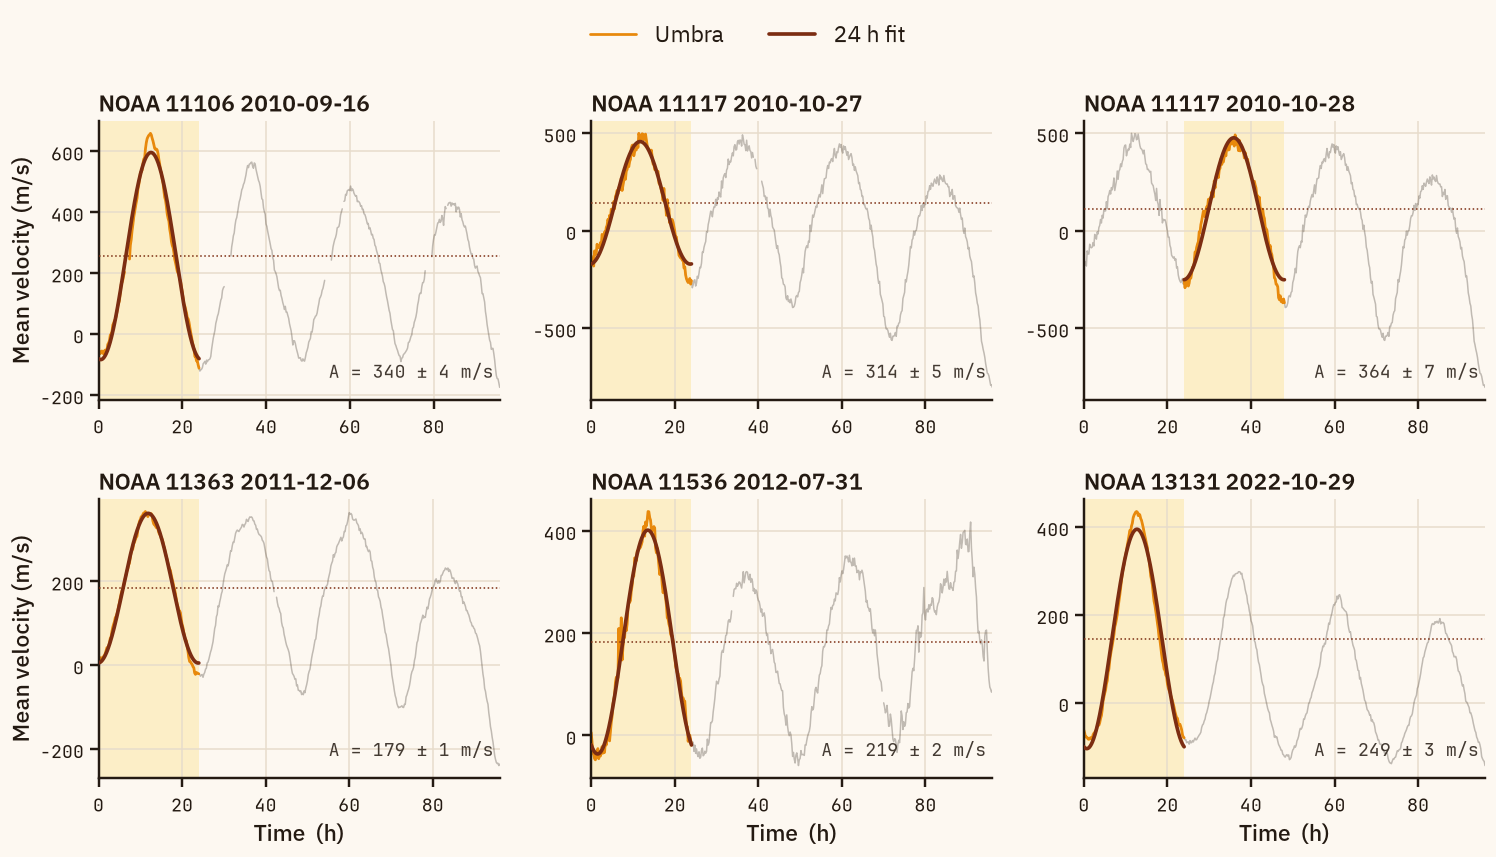

In [ ]:
# The six 24 h fits, one panel each — the in-notebook restyle of
# comparison.plot_diurnal_fits(fit_rows, series_key='fit_rel', save=SAVE,
#                              plots_dir=config.PROCESSED_DIR / 'plots')
SERIES_KEY = 'fit_rel'
VALUE_KEY  = 'series_rel' if SERIES_KEY == 'fit_rel' else 'series'
YLABEL     = ('Mean velocity (m/s)' if SERIES_KEY == 'fit_rel'
              else 'Umbra, absolute  (m/s)')

# Six panels in 12 × 8 in is 6 × 2.7 in each; the deck's 26/20/17 pt type would swamp
# them, so only the sizes step down — colours, grid, spines and mono ticks are the theme's.
FS_PANEL = 15
FS_SMALL = 12

panels = [r for r in fit_rows if np.isfinite(r[SERIES_KEY]['amplitude'])]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
flat = axes.ravel()

for ax, row in zip(flat, panels):
    fit  = row[SERIES_KEY]
    t, y = row['time_h'], row[VALUE_KEY]
    t0, t1 = fit['window']

    # Whole record faint with the window shaded, fitted stretch in umbra amber on top: a
    # window sitting on an unrepresentative piece of the series is then obvious.
    ax.axvspan(t0, t1, color=C_SERIES_2, alpha=0.25, lw=0, zorder=0)
    ax.plot(t, y, color=C_INK, alpha=0.28, lw=1.0, zorder=1)
    inside = (t >= t0) & (t <= t1)
    ax.plot(t[inside], y[inside], color=C_SERIES_1, lw=1.8, zorder=2, label='Umbra')

    dense = np.linspace(t0, t1, 400)
    ax.plot(dense, oscillation.diurnal_curve(fit, dense), color=C_SERIES_3, lw=2.4,
            zorder=3, label=f'{fit["period_h"]:g} h fit')
    ax.axhline(fit['intercept'], color=C_SERIES_3, lw=1.0, ls=':', zorder=3)

    ax.set_title(row['label'], loc='left', fontsize=FS_PANEL, pad=6)
    ax.annotate(f'A = {fit["amplitude"]:.0f} ± {fit["sigma_amplitude"]:.0f} m/s',
                xy=(0.985, 0.06), xycoords='axes fraction', ha='right', va='bottom',
                fontsize=FS_SMALL, family='monospace', color=C_INK, alpha=0.85)
    ax.set_xlim(float(np.nanmin(t)), float(np.nanmax(t)))

    # mono_ticks() would put the deck's 17 pt on labels this size, so the same thing at
    # the panel size instead.
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontfamily('monospace')
        tick.set_fontsize(FS_SMALL)

# Axis labels only on the outer edge: at 6 × 2.7 in a label per panel is all there is room for.
n_cols = axes.shape[1]
for i, ax in enumerate(flat):
    if i >= len(panels):
        ax.set_visible(False)
        continue
    if i % n_cols == 0:
        ax.set_ylabel(YLABEL, fontsize=FS_PANEL)
    if i >= len(panels) - n_cols:
        ax.set_xlabel('Time  (h)', fontsize=FS_PANEL)

fig.tight_layout(rect=(0, 0, 1, 0.93))

# One legend for all six panels, in its own band above the titles.
fig.legend(*flat[0].get_legend_handles_labels(), ncol=2, loc='upper center',
           bbox_to_anchor=(0.5, 1.0), frameon=False, fontsize=FS_PANEL)

save_loptien_fig(fig, f'diurnal_{SERIES_KEY}')

plt.show()

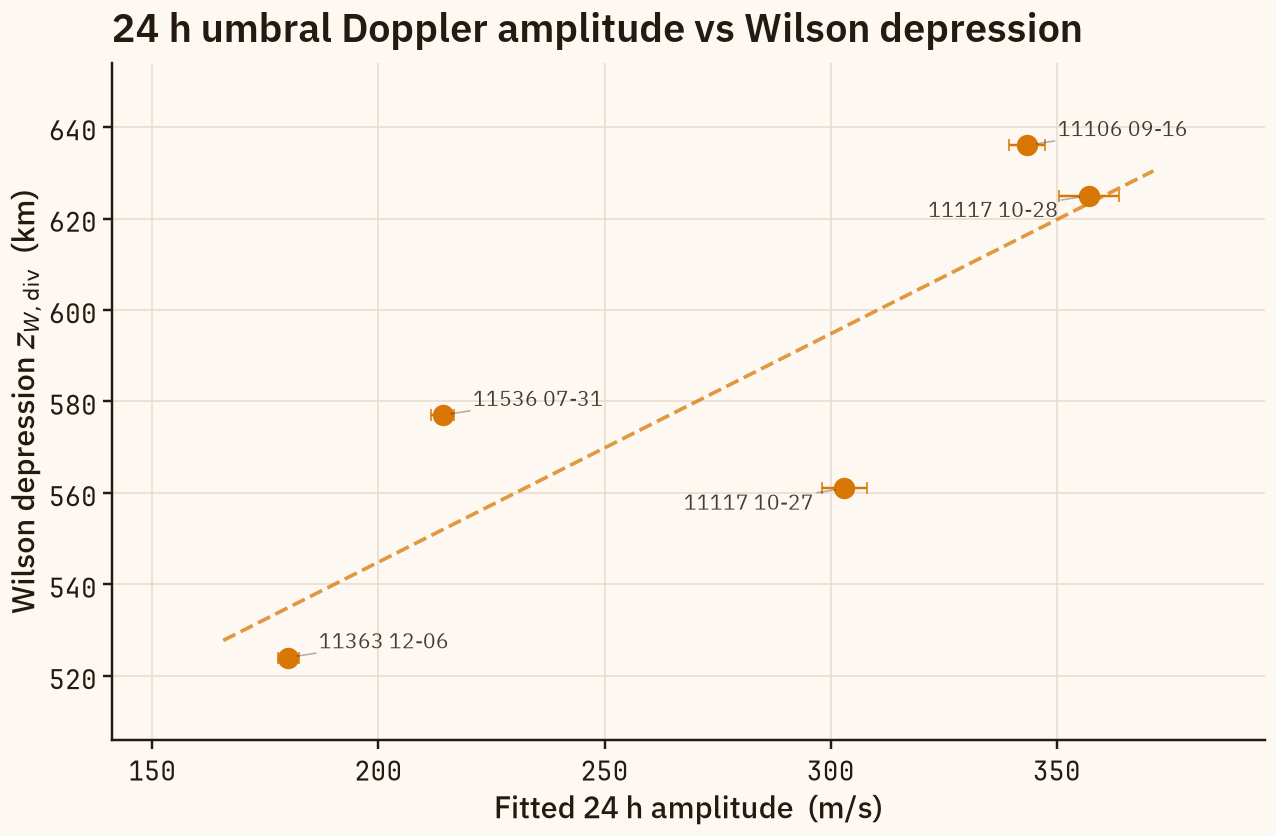

Linear fit   z_div = m · A + b      (A = fitted 24 h amplitude in m/s, z in km)
──────────────────────────────────────────────────────────────────────────────
Umbra, absolute      m =   +0.499 ± 0.179 km/(m/s)
                     b =   +445.0 ± 51.5 km
                     z_div = +0.499 · A +445.0    r = +0.85,  n = 5

Six points: this describes the sample, it is not evidence of a relationship.


In [ ]:
# 24 h amplitude vs the divergence-method Wilson depression — with a linear fit
DEPTH_KEY = 'z_div_km'

fig, ax = plt.subplots(figsize=(12, 8))
equations = []

# Markers first, then the fit lines, so the legend reads marker / fit per series.
for suffix, colour, marker, name in FIT_SERIES:
    ax.errorbar(fits[f'amplitude_{suffix}'], fits[DEPTH_KEY],
                xerr=fits[f'sigma_amplitude_{suffix}'], fmt=marker, color=colour,
                ms=13, capsize=4, lw=0, elinewidth=1.6, label=name)

for suffix, colour, marker, name in FIT_SERIES:
    x = fits[f'amplitude_{suffix}'].to_numpy(float)
    y = fits[DEPTH_KEY].to_numpy(float)
    fit = linear_fit(x, y)
    if fit is None:
        continue
    grid = np.linspace(x.min() * 0.92, x.max() * 1.04, 100)
    ax.plot(grid, fit['slope'] * grid + fit['intercept'], color=colour,
            lw=LW_SERIES, ls='--', alpha=0.75,
            label=f'   fit,  r = {fit["r"]:+.2f}  (n = {fit["n"]})')
    equations.append((name, fit))

# NOAA number + MM-DD, short enough not to crowd but still separating 11117's two
# windows. Points adjacent in y get opposite vertical offsets, which is what stops
# 11106 and 11117 10-28 — 11 km apart — from writing over each other.
_rank = {idx: rank for rank, idx in enumerate(np.argsort(fits[DEPTH_KEY].to_numpy(float)))}
# 11106 and 11117 10-28 sit 24 m/s and 11 km apart, close enough that no fixed offset
# separates their labels — so every label gets a leader line and is pushed well clear,
# alternating side by neighbour-in-y.
for i, (_, r) in enumerate(fits.iterrows()):
    down = _rank[i] % 2 == 0
    ax.annotate(f'{int(r["noaa"])} {str(r["date"])[5:]}',
                (r['amplitude_abs'], r[DEPTH_KEY]), textcoords='offset points',
                xytext=(20, 10) if down else (-20, -10),
                ha='left' if down else 'right', va='center',
                fontsize=FS_ANNOT, color=C_INK, alpha=0.85,
                arrowprops=dict(arrowstyle='-', color=C_INK, alpha=0.35, lw=1.0,
                                shrinkA=0, shrinkB=6))

ax.set_xlabel(f'Fitted {fits["period_h"].iloc[0]:g} h amplitude  (m/s)')
ax.set_ylabel(f'Wilson depression {DEPTH_LABEL[DEPTH_KEY]}  (km)')
ax.set_title('24 h umbral Doppler amplitude vs Wilson depression', loc='left')
ax.margins(x=0.12, y=0.16)      # headroom so the leader-line labels are not clipped
#ax.legend(loc='best')

mono_ticks(ax)
fig.tight_layout()
save_loptien_fig(fig, 'amplitude_vs_z_div')
plt.show()

# The equation, outside the figure.
print('Linear fit   z_div = m · A + b      (A = fitted 24 h amplitude in m/s, z in km)')
print('─' * 78)
for name, f in equations:
    print(f'{name:<20} m = {f["slope"]:+8.3f} ± {f["sigma_slope"]:.3f} km/(m/s)')
    print(f'{"":<20} b = {f["intercept"]:+8.1f} ± {f["sigma_intercept"]:.1f} km')
    print(f'{"":<20} z_div = {f["slope"]:+.3f} · A {f["intercept"]:+.1f}    '
          f'r = {f["r"]:+.2f},  n = {f["n"]}')
    print()
print('Six points: this describes the sample, it is not evidence of a relationship.')

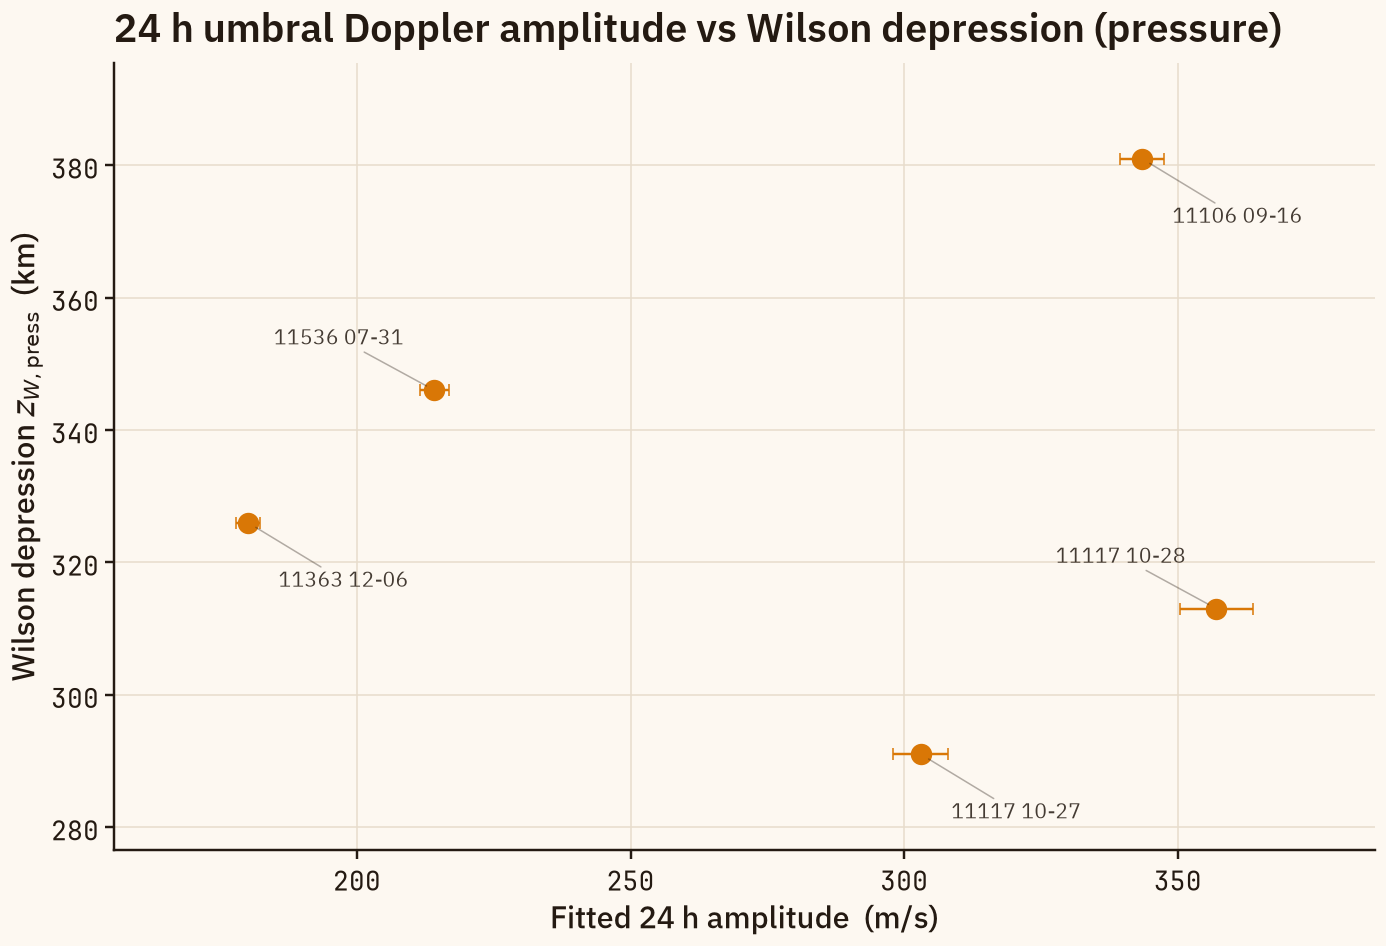

In [ ]:
# 24 h amplitude vs the pressure-method Wilson depression
DEPTH_KEY = 'z_press_km'

fig, ax = plt.subplots(figsize=(13, 9))

for suffix, colour, marker, name in FIT_SERIES:
    ax.errorbar(fits[f'amplitude_{suffix}'], fits[DEPTH_KEY],
                xerr=fits[f'sigma_amplitude_{suffix}'], fmt=marker, color=colour,
                ms=13, capsize=4, lw=0, elinewidth=1.6, label=name)
    fit = linear_fit(fits[f'amplitude_{suffix}'].to_numpy(float),
                     fits[DEPTH_KEY].to_numpy(float))
    if fit is not None:
        ax.plot([], [], ' ', label=f'   r = {fit["r"]:+.2f}  (n = {fit["n"]})')

# NOAA number + MM-DD, short enough not to crowd but still separating 11117's two
# windows. Points adjacent in y get opposite vertical offsets, which is what stops
# 11106 and 11117 10-28 — 11 km apart — from writing over each other.
_rank = {idx: rank for rank, idx in enumerate(np.argsort(fits[DEPTH_KEY].to_numpy(float)))}
# 11106 and 11117 10-28 sit 24 m/s and 11 km apart, close enough that no fixed offset
# separates their labels — so every label gets a leader line and is pushed well clear,
# alternating side by neighbour-in-y.
for i, (_, r) in enumerate(fits.iterrows()):
    down = _rank[i] % 2 == 0
    ax.annotate(f'{int(r["noaa"])} {str(r["date"])[5:]}',
                (r['amplitude_abs'], r[DEPTH_KEY]), textcoords='offset points',
                xytext=(20, -38) if down else (-20, 34),
                ha='left' if down else 'right', va='center',
                fontsize=FS_ANNOT, color=C_INK, alpha=0.85,
                arrowprops=dict(arrowstyle='-', color=C_INK, alpha=0.35, lw=1.0,
                                shrinkA=0, shrinkB=6))

ax.set_xlabel(f'Fitted {fits["period_h"].iloc[0]:g} h amplitude  (m/s)')
ax.set_ylabel(f'Wilson depression {DEPTH_LABEL[DEPTH_KEY]}  (km)')
ax.set_title('24 h umbral Doppler amplitude vs Wilson depression (pressure)', loc='left')
ax.margins(x=0.12, y=0.16)      # headroom so the leader-line labels are not clipped
#ax.legend(loc='best')

mono_ticks(ax)
fig.tight_layout()
save_loptien_fig(fig, 'amplitude_vs_z_press')
plt.show()

---

# A dopplergram loop for the deck

Not a diagnostic. `anim.html` beside `metrics.csv` is the diagnostic — three channels, the
umbra and penumbra outlined on each, axes, legends and colorbars, and only every
`n_t // 60`-th frame, so the spot visibly jumps from one frame to the next.

This is the other thing: DS01's dopplergram alone, **every one of the 1067 frames** at the
720 s cadence so the motion is continuous, and nothing on the image but the image — no axes,
no ticks, no grid, no colorbar, no masks. It goes on a slide as a looping element, so
anything that reads as a figure works against it.

The hue is the animation's, unchanged: `RdBu_r` between −vmax and +vmax, with vmax the 99th
percentile of |v| — `plotting.symmetric_limits`, the same rule `save_animation` applies when
`dop_symmetric_cbar=True`. Zero velocity is therefore the colormap's white midpoint and a
blueshift reads the same size as a redshift of equal magnitude. The limit is computed once
over the whole sequence and held fixed, which is what stops the background from pulsing as
the loop plays.

The frames are written to `frames_anim_custum/` inside DS01's processed folder as
`frame_0000.png` … `frame_1066.png`, ready for `ffmpeg -i frame_%04d.png`; the cell prints
the two commands that assemble the `.gif`.

1067 frames already in frames_anim_custum — set RENDER_FRAMES = True to re-render

preview: frame_0533.png


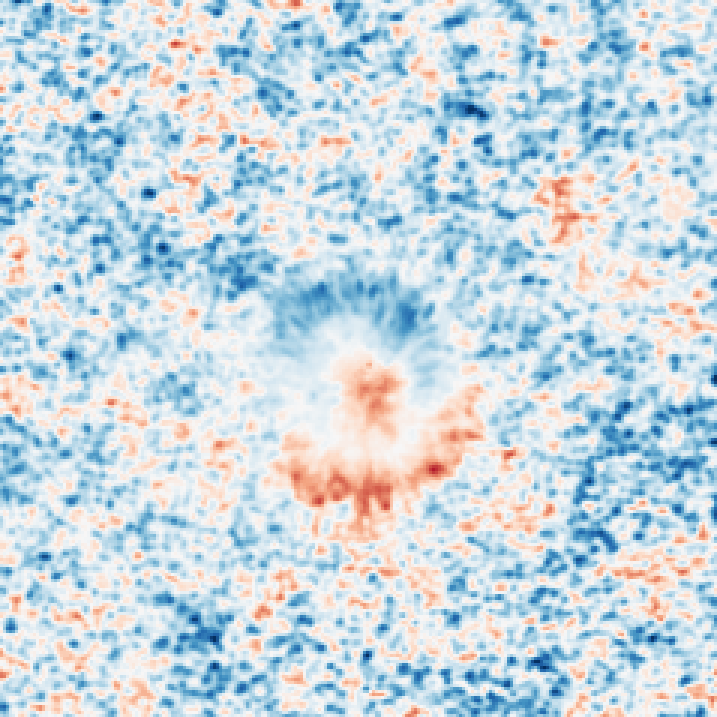


Build the gif in /mnt/shared/Projects/sun_spots_pulsation_review/data/processed/sebastian_sun_spots/DS01/frames_anim_custum:
  ffmpeg -framerate 20 -i frame_%04d.png -vf "split[a][b];[a]palettegen[p];[b][p]paletteuse" animation.gif
  magick -delay 5 -loop 0 'frame_*.png' animation.gif


In [ ]:
"""DS01's dopplergram, every frame, bare — PNGs for the deck's .gif."""

from astropy.io import fits

from src.plotting import symmetric_limits

FRAMES_DIR    = OUT_DIR / 'frames_anim_custum'
RENDER_FRAMES = False      # True re-renders; a no-op once the frames are on disk
FRAME_STEP    = 1          # every frame — a continuous loop is the whole point
FRAME_SCALE   = 3          # 239 px cube → 717 px PNGs
FILL          = 1e6        # IDL fill value, same as loaders._load_cube
DOP_CUBE      = RAW_DIR / 'cube_dopplergram_corrected.fits'   # calibrated, not reconstructed

# NaN — a gap frame, or fill — as a flat card in the deck's background rather than a
# transparent hole that shows the slide through it.
CMAP_DOP = plt.get_cmap('RdBu_r').copy()
CMAP_DOP.set_bad(C_FIG_BG)

existing = sorted(FRAMES_DIR.glob('frame_*.png')) if FRAMES_DIR.exists() else []

if RENDER_FRAMES or not existing:
    FRAMES_DIR.mkdir(parents=True, exist_ok=True)
    for stale in existing:                     # a shorter run must not leave a tail behind
        stale.unlink()

    with fits.open(DOP_CUBE, memmap=True) as hdul:
        cube = hdul[0].data                    # (n_t, ny, nx), never held whole
        n_t, ny, nx = cube.shape
        frames_idx = np.arange(0, n_t, FRAME_STEP)

        # One sampling pass for the colour limit, then it is fixed for every frame.
        sample = np.asarray(cube[::20], dtype=np.float32)
        sample[np.abs(sample) > FILL] = np.nan
        vmax = symmetric_limits(sample, percentile=99)
        del sample

        # The axes fill the figure, so the saved PNG is the image and nothing else.
        fig = plt.figure(figsize=(nx / 100, ny / 100), dpi=100, facecolor=C_FIG_BG)
        ax  = fig.add_axes((0, 0, 1, 1))
        ax.set_axis_off()
        frame0 = np.asarray(cube[0], dtype=np.float32)
        frame0[np.abs(frame0) > FILL] = np.nan
        im = ax.imshow(frame0, origin='lower', cmap=CMAP_DOP, vmin=-vmax, vmax=vmax,
                       interpolation='nearest')

        for k, t in enumerate(frames_idx):
            frame = np.asarray(cube[t], dtype=np.float32)
            frame[np.abs(frame) > FILL] = np.nan
            im.set_data(frame)
            # bbox_inches=None overrides the notebook's savefig.bbox='tight': tight
            # re-crops every frame on its own content, and frames of different pixel
            # sizes make the gif jitter.
            fig.savefig(FRAMES_DIR / f'frame_{k:04d}.png', dpi=100 * FRAME_SCALE,
                        bbox_inches=None, pad_inches=0, facecolor=C_FIG_BG)

    plt.close(fig)
    size_mb = sum(f.stat().st_size for f in FRAMES_DIR.glob('frame_*.png')) / 1e6
    print(f'{len(frames_idx)} frames → {FRAMES_DIR}  '
          f'({nx * FRAME_SCALE}×{ny * FRAME_SCALE} px, {size_mb:.0f} MB)')
    print(f'colour limits: ±{vmax:.0f} m/s  (99th percentile of |v|, fixed for the sequence)')
else:
    print(f'{len(existing)} frames already in {FRAMES_DIR.name} — '
          f'set RENDER_FRAMES = True to re-render')

# One frame from the middle, at the size it was written, as the check that it is bare.
frames = sorted(FRAMES_DIR.glob('frame_*.png'))
if frames:
    from IPython.display import Image, display

    middle = frames[len(frames) // 2]
    print(f'\npreview: {middle.name}')
    display(Image(filename=str(middle), width=420))

print(f'\nBuild the gif in {FRAMES_DIR}:')
print('  ffmpeg -framerate 20 -i frame_%04d.png '
      '-vf "split[a][b];[a]palettegen[p];[b][p]paletteuse" animation.gif')
print("  magick -delay 5 -loop 0 'frame_*.png' animation.gif")